# Phase 1: Cross-Subject EEG Motor Imagery Classification using EEGNet

This notebook builds the first baseline for the project using EEGNet on the BCI Competition IV 2a dataset.

## Objective

The goal is to classify EEG motor imagery trials into four classes:

- Left hand
- Right hand
- Feet
- Tongue

We use a cross-subject setting:

- source domain: 6 subjects for training
- target domain: 3 unseen subjects for testing

This first phase focuses only on building a strong EEGNet baseline before introducing domain adaptation methods.

## Step 1: Mount Google Drive

We first mount Google Drive so the notebook can access the raw `.gdf` EEG files stored in the `EEG Signal Processing` folder.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#Import EEG Processing Library
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 52.5 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


## Step 2: Import Libraries

We import the required libraries for EEG loading, event extraction, preprocessing, model building, training, and evaluation.

In [8]:
import os
import numpy as np
import pandas as pd
from collections import Counter

import mne
from mne.io import read_raw_gdf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

## Step 3: Define Dataset Path

The raw training files are stored in the `EEG Signal Processing` folder in Google Drive.

For this baseline, we use only the training session files ending with `T.gdf`.

In [9]:
DATA_DIR = "/content/drive/MyDrive/EEG Signal Processing"

train_files = sorted([
    f for f in os.listdir(DATA_DIR)
    if f.endswith("T.gdf")
])

print("Training files:")
print(train_files)
print("Number of training files:", len(train_files))

Training files:
['A01T.gdf', 'A02T.gdf', 'A03T.gdf', 'A04T.gdf', 'A05T.gdf', 'A06T.gdf', 'A07T.gdf', 'A08T.gdf', 'A09T.gdf']
Number of training files: 9


## Step 4: Define a Subject Loading Function

We define a reusable function that:

1. loads one `.gdf` file
2. keeps only EEG channels
3. extracts the four motor imagery classes
4. epochs the EEG trials from the motor imagery interval
5. returns:
   - `X`: EEG trials
   - `y`: class labels
   - `subject_ids`: subject index for each trial

The BCI Competition IV 2a motor imagery event codes are:

- `769` → left hand
- `770` → right hand
- `771` → feet
- `772` → tongue

In [10]:
def load_subject_trials(file_path, subject_id, tmin=2.0, tmax=6.0):
    raw = read_raw_gdf(file_path, preload=True, verbose=False)

    # Keep only EEG channels
    eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False)
    raw.pick(eeg_picks)

    # Extract events
    events, event_id = mne.events_from_annotations(raw, verbose=False)

    # Standard motor imagery event codes for BCI IV 2a
    possible_mi_keys = ["769", "770", "771", "772"]
    selected_keys = [k for k in possible_mi_keys if k in event_id]

    if len(selected_keys) != 4:
        print(f"Could not find the 4 motor imagery classes in {os.path.basename(file_path)}")
        print("Available event keys:", list(event_id.keys()))
        return None, None, None

    selected_event_id = {k: event_id[k] for k in selected_keys}

    epochs = mne.Epochs(
        raw,
        events,
        event_id=selected_event_id,
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        preload=True,
        verbose=False
    )

    X = epochs.get_data()          # shape: (n_trials, n_channels, n_times)
    X = X[:, :22, :]               # keep the first 22 EEG channels

    unique_codes = sorted(selected_event_id.values())
    code_to_label = {code: idx for idx, code in enumerate(unique_codes)}
    y = np.array([code_to_label[event[-1]] for event in epochs.events], dtype=np.int64)

    subject_ids = np.full(len(y), subject_id, dtype=np.int64)

    return X, y, subject_ids

## Step 5: Load All Subject Training Files

We now process all 9 subject training files and combine them into one dataset.

In [11]:
X_all = []
y_all = []
subjects_all = []

for i, file in enumerate(train_files):
    file_path = os.path.join(DATA_DIR, file)

    X_sub, y_sub, s_sub = load_subject_trials(file_path, subject_id=i)

    if X_sub is None:
        continue

    X_all.append(X_sub)
    y_all.append(y_sub)
    subjects_all.append(s_sub)

X = np.concatenate(X_all, axis=0)
y = np.concatenate(y_all, axis=0)
subjects = np.concatenate(subjects_all, axis=0)

print("Final dataset:")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("subjects shape:", subjects.shape)
print("Unique labels:", np.unique(y))
print("Unique subjects:", np.unique(subjects))

/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying runni

Final dataset:
X shape: (2583, 22, 1001)
y shape: (2583,)
subjects shape: (2583,)
Unique labels: [0 1 2 3]
Unique subjects: [0 1 2 3 4 5 6 7 8]


## Step 6: Define the Cross-Subject Split

We create a cross-subject evaluation setup:

- source subjects: 0 to 5
- target subjects: 6 to 8

This allows us to train on one group of subjects and evaluate on unseen subjects.

In [12]:
unique_subjects = np.unique(subjects)

source_subjects = unique_subjects[:6]
target_subjects = unique_subjects[6:9]

print("Source subjects:", source_subjects)
print("Target subjects:", target_subjects)

source_mask = np.isin(subjects, source_subjects)
target_mask = np.isin(subjects, target_subjects)

X_source = X[source_mask]
y_source = y[source_mask]

X_target = X[target_mask]
y_target = y[target_mask]

print("\nAfter split:")
print("X_source:", X_source.shape)
print("y_source:", y_source.shape)
print("X_target:", X_target.shape)
print("y_target:", y_target.shape)

Source subjects: [0 1 2 3 4 5]
Target subjects: [6 7 8]

After split:
X_source: (1722, 22, 1001)
y_source: (1722,)
X_target: (861, 22, 1001)
y_target: (861,)


## Step 7: Inspect Class Distribution

We check the label distribution in the source and target sets.

In [13]:
print("Source label distribution:", Counter(y_source))
print("Target label distribution:", Counter(y_target))

Source label distribution: Counter({np.int64(3): 432, np.int64(1): 432, np.int64(0): 430, np.int64(2): 428})
Target label distribution: Counter({np.int64(0): 216, np.int64(1): 216, np.int64(3): 216, np.int64(2): 213})


## Step 8: Normalize EEG Data

We standardize the EEG signals channel-wise using statistics from the source set only.

This prevents data leakage from the target domain.

In [14]:
def standardize_eeg_train_test(X_train, X_test):
    X_train_std = np.zeros_like(X_train, dtype=np.float32)
    X_test_std = np.zeros_like(X_test, dtype=np.float32)

    _, C, _ = X_train.shape

    for ch in range(C):
        scaler = StandardScaler()
        scaler.fit(X_train[:, ch, :])

        X_train_std[:, ch, :] = scaler.transform(X_train[:, ch, :])
        X_test_std[:, ch, :] = scaler.transform(X_test[:, ch, :])

    return X_train_std, X_test_std

X_source, X_target = standardize_eeg_train_test(X_source, X_target)

print("After normalization:")
print("X_source:", X_source.shape)
print("X_target:", X_target.shape)

After normalization:
X_source: (1722, 22, 1001)
X_target: (861, 22, 1001)


## Step 9: Create PyTorch Datasets and DataLoaders

We convert the EEG arrays into PyTorch datasets and loaders for mini-batch training and evaluation.

In [15]:
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64

train_dataset = EEGDataset(X_source, y_source)
test_dataset = EEGDataset(X_target, y_target)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))
print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train dataset size: 1722
Test dataset size: 861
Train batches: 27
Test batches: 14


## Step 10: Define EEGNet

EEGNet is a compact neural network designed specifically for EEG classification.

In this implementation:

- the input shape is `(batch, channels, time)`
- the convolution channel is added inside the model
- the classifier size is computed safely using a dummy forward pass

In [16]:
class EEGNet(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=1001, dropout=0.5):
        super(EEGNet, self).__init__()

        self.features = nn.Sequential(
            # Temporal convolution
            nn.Conv2d(1, 16, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16),

            # Depthwise spatial convolution
            nn.Conv2d(16, 32, kernel_size=(n_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),

            # Separable-style temporal convolution
            nn.Conv2d(32, 32, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            dummy_out = self.features(dummy)
            flattened_dim = dummy_out.view(1, -1).shape[1]

        self.classifier = nn.Linear(flattened_dim, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)          # (B, 1, C, T)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

## Step 11: Verify EEGNet Output Shape

Before training, we confirm that EEGNet accepts the EEG batch and produces one output vector per trial.

In [17]:
eegnet = EEGNet(n_channels=22, n_classes=4, n_times=1001)

sample_batch, sample_labels = next(iter(train_loader))
output = eegnet(sample_batch)

print("Input batch shape:", sample_batch.shape)
print("Output shape:", output.shape)

Input batch shape: torch.Size([64, 22, 1001])
Output shape: torch.Size([64, 4])


## Step 12: Define Training and Evaluation Functions

We define reusable functions for:

- one training epoch
- one evaluation pass

The model is trained on the source subjects and evaluated on the unseen target subjects using:

- loss
- accuracy
- macro F1-score

In [18]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(y_batch.detach().cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1


def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y_batch.detach().cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds)

## Step 13: Initialize EEGNet Training

In [19]:
eegnet = EEGNet(n_channels=22, n_classes=4, n_times=1001)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(eegnet.parameters(), lr=1e-3)

## Step 14: Train EEGNet

We train EEGNet on the source subjects and evaluate it on the unseen target subjects after each epoch.

The best model is selected using the highest target macro F1-score.

In [20]:
epochs = 30

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "test_loss": [],
    "test_acc": [],
    "test_f1": []
}

best_f1 = 0.0
best_state = None

for epoch in range(1, epochs + 1):
    train_loss, train_acc, train_f1 = train_one_epoch(eegnet, train_loader, optimizer, criterion)
    test_loss, test_acc, test_f1, y_true, y_pred = evaluate(eegnet, test_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    history["test_f1"].append(test_f1)

    if test_f1 > best_f1:
        best_f1 = test_f1
        best_state = {k: v.clone() for k, v in eegnet.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f}"
    )

if best_state is not None:
    eegnet.load_state_dict(best_state)

Epoch 01/30 | Train Loss: 1.4303 | Train Acc: 0.2602 | Train F1: 0.2601 | Test Loss: 1.3986 | Test Acc: 0.2753 | Test F1: 0.2680
Epoch 02/30 | Train Loss: 1.3701 | Train Acc: 0.3171 | Train F1: 0.3159 | Test Loss: 1.4115 | Test Acc: 0.2578 | Test F1: 0.2573
Epoch 03/30 | Train Loss: 1.3414 | Train Acc: 0.3368 | Train F1: 0.3366 | Test Loss: 1.4347 | Test Acc: 0.2718 | Test F1: 0.2628
Epoch 04/30 | Train Loss: 1.3067 | Train Acc: 0.3978 | Train F1: 0.3976 | Test Loss: 1.4231 | Test Acc: 0.2962 | Test F1: 0.2897
Epoch 05/30 | Train Loss: 1.2877 | Train Acc: 0.3914 | Train F1: 0.3894 | Test Loss: 1.4368 | Test Acc: 0.2973 | Test F1: 0.2936
Epoch 06/30 | Train Loss: 1.2551 | Train Acc: 0.4210 | Train F1: 0.4213 | Test Loss: 1.4405 | Test Acc: 0.3008 | Test F1: 0.2953
Epoch 07/30 | Train Loss: 1.2411 | Train Acc: 0.4297 | Train F1: 0.4295 | Test Loss: 1.4588 | Test Acc: 0.3031 | Test F1: 0.2990
Epoch 08/30 | Train Loss: 1.2213 | Train Acc: 0.4489 | Train F1: 0.4490 | Test Loss: 1.4940 | Tes

## Step 15: Final Evaluation

After training, we evaluate the best EEGNet model on the unseen target subjects.

In [21]:
test_loss, test_acc, test_f1, y_true, y_pred = evaluate(eegnet, test_loader, criterion)

print("Final Test Loss:", round(test_loss, 4))
print("Final Test Accuracy:", round(test_acc, 4))
print("Final Test Macro F1:", round(test_f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Final Test Loss: 1.5674
Final Test Accuracy: 0.3531
Final Test Macro F1: 0.3542

Classification Report:

              precision    recall  f1-score   support

           0       0.40      0.28      0.33       216
           1       0.45      0.39      0.42       216
           2       0.26      0.32      0.29       213
           3       0.34      0.42      0.38       216

    accuracy                           0.35       861
   macro avg       0.36      0.35      0.35       861
weighted avg       0.36      0.35      0.35       861



## Step 16: Confusion Matrix

We inspect the confusion matrix to understand which classes are being confused by the model.

In [17]:
cm = confusion_matrix(y_true, y_pred)
pd.DataFrame(cm)

,0,1,2,3
0,47,62,61,46
1,23,90,63,40
2,33,61,72,47
3,19,52,80,65


## Step 17: Plot Training History

We visualize the training and target-domain evaluation across epochs.

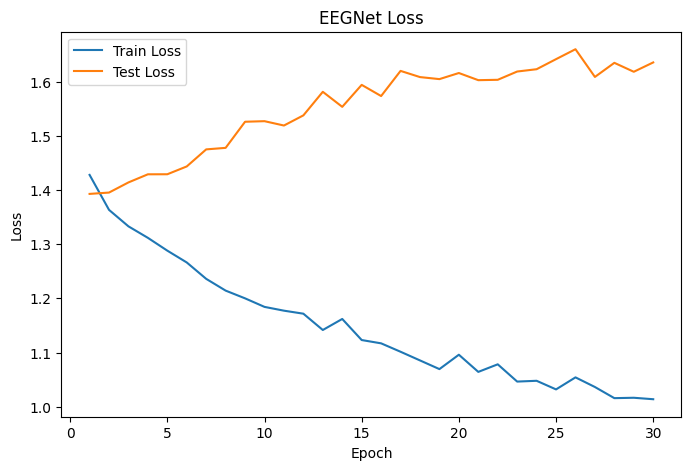

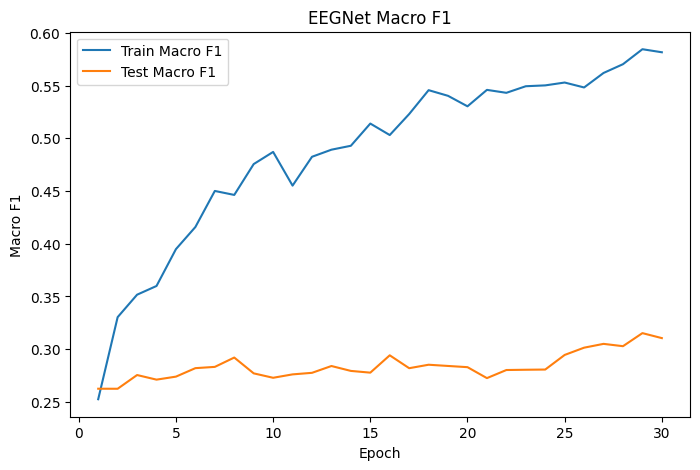

In [18]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["test_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EEGNet Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_f1"], label="Train Macro F1")
plt.plot(epochs_range, history["test_f1"], label="Test Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("EEGNet Macro F1")
plt.legend()
plt.show()

# Phase 2: Addressing Domain Shift in Cross-Subject EEG Learning

## Why Domain Adaptation is Needed

The supervised EEGNet baseline showed limited performance on unseen target subjects. This performance gap reflects the presence of **domain shift** between source and target EEG distributions.

In cross-subject EEG motor imagery classification, domain shift arises because different subjects produce neural signals with different statistical properties, even when performing the same motor imagery task. As a result, a model trained only on source subjects often learns representations that do not transfer well to new individuals.

To address this, we now introduce domain adaptation methods that aim to reduce the discrepancy between source and target domains.

---

## What We Will Do Next

We will progressively investigate domain adaptation techniques, beginning with a simple and effective statistical alignment method.

The first method we implement is:

### DeepCORAL (Deep Correlation Alignment)

DeepCORAL aligns the **covariance structure** of source and target feature representations.

Instead of using adversarial training, it directly minimizes the difference between the second-order statistics of the two domains.

This makes it a good first adaptation method because it is:

- simple to implement
- stable to train
- effective as an early domain adaptation baseline

---

## Method 1: DeepCORAL

### Definition

DeepCORAL is a domain adaptation method that aligns source and target feature distributions by matching their covariance matrices.

### Core Idea

If source and target features have similar covariance structure, the feature space becomes more transferable across domains.

### Why It Fits This Project

In EEG, domain shift often appears as changes in signal distribution across subjects. DeepCORAL provides a simple way to reduce this mismatch without changing the class labels or using adversarial optimization.

### Training Objective

The total loss becomes:

- source classification loss
- plus CORAL alignment loss between source and target features

This allows the model to remain discriminative for motor imagery classification while also learning more domain-invariant representations.

## DeepCORAL Loss

Let:

- `F_s` be the source feature matrix
- `F_t` be the target feature matrix

DeepCORAL computes the covariance of both domains and minimizes their difference.

The total loss is:

\[
\mathcal{L} = \mathcal{L}_{cls} + \lambda \mathcal{L}_{CORAL}
\]

Where:

- `L_cls` is the source classification loss
- `L_CORAL` is the covariance alignment loss
- `λ` controls the strength of adaptation

In this notebook, we use EEGNet as the feature extractor and classifier, and we apply CORAL loss to the learned feature representation before the final classification layer.

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

class EEGNetCORAL(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=1001, dropout=0.5):
        super(EEGNetCORAL, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, kernel_size=(n_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),

            nn.Conv2d(32, 32, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            dummy_out = self.features(dummy)
            flattened_dim = dummy_out.view(1, -1).shape[1]

        self.classifier = nn.Linear(flattened_dim, n_classes)

    def extract_features(self, x):
        x = x.unsqueeze(1)          # (B, 1, C, T)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return x

    def forward(self, x):
        feats = self.extract_features(x)
        logits = self.classifier(feats)
        return logits, feats

In [30]:
def coral_loss(source, target):
    """
    CORAL loss between source and target feature representations.
    source: (Ns, D)
    target: (Nt, D)
    """
    d = source.size(1)

    # Center features
    source_centered = source - source.mean(dim=0, keepdim=True)
    target_centered = target - target.mean(dim=0, keepdim=True)

    # Covariance
    cov_source = (source_centered.T @ source_centered) / (source.size(0) - 1)
    cov_target = (target_centered.T @ target_centered) / (target.size(0) - 1)

    loss = torch.mean((cov_source - cov_target) ** 2)
    loss = loss / (4 * d * d)
    return loss

## Preparing Source and Target Mini-Batches

DeepCORAL needs:

- labeled source batches for classification
- unlabeled target batches for domain alignment

So during training, we iterate through both source and target loaders together.

In [31]:
# Reuse your existing normalized arrays:
# X_source, y_source, X_target, y_target

train_dataset = EEGDataset(X_source, y_source)
target_dataset = EEGDataset(X_target, y_target)   # labels won't be used in training
test_dataset = EEGDataset(X_target, y_target)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
target_loader = DataLoader(target_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Source batches:", len(train_loader))
print("Target batches:", len(target_loader))
print("Test batches:", len(test_loader))

Source batches: 27
Target batches: 14
Test batches: 14


## Training DeepCORAL

We now train EEGNet with two objectives:

1. classify source EEG trials correctly
2. align source and target feature covariance using CORAL loss

This allows the network to learn features that are both discriminative and more transferable across subjects.

In [32]:
def train_deepcoral(model, source_loader, target_loader, test_loader, epochs=30, lr=1e-3, lambda_coral=1.0):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_cls_loss": [],
        "train_coral_loss": [],
        "test_loss": [],
        "test_acc": [],
        "test_f1": []
    }

    best_f1 = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()

        total_cls_loss = 0.0
        total_coral_loss = 0.0

        target_iter = iter(target_loader)

        for Xs, ys in source_loader:
            try:
                Xt, _ = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                Xt, _ = next(target_iter)

            optimizer.zero_grad()

            source_logits, source_feats = model(Xs)
            _, target_feats = model(Xt)

            cls_loss = criterion(source_logits, ys)
            da_loss = coral_loss(source_feats, target_feats)

            loss = cls_loss + lambda_coral * da_loss
            loss.backward()
            optimizer.step()

            total_cls_loss += cls_loss.item() * Xs.size(0)
            total_coral_loss += da_loss.item() * Xs.size(0)

        avg_cls_loss = total_cls_loss / len(source_loader.dataset)
        avg_coral_loss = total_coral_loss / len(source_loader.dataset)

        test_loss, test_acc, test_f1, y_true, y_pred = evaluate_deepcoral(model, test_loader, criterion)

        history["train_cls_loss"].append(avg_cls_loss)
        history["train_coral_loss"].append(avg_coral_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["test_f1"].append(test_f1)

        if test_f1 > best_f1:
            best_f1 = test_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(
            f"[DeepCORAL] Epoch {epoch:02d}/{epochs} | "
            f"Cls Loss: {avg_cls_loss:.4f} | CORAL Loss: {avg_coral_loss:.6f} | "
            f"Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [33]:
def evaluate_deepcoral(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits, _ = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y_batch.detach().cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds)

In [34]:
deepcoral_model = EEGNetCORAL(n_channels=22, n_classes=4, n_times=1001)

deepcoral_model, history_coral = train_deepcoral(
    deepcoral_model,
    train_loader,
    target_loader,
    test_loader,
    epochs=30,
    lr=1e-3,
    lambda_coral=1.0
)

[DeepCORAL] Epoch 01/30 | Cls Loss: 1.4087 | CORAL Loss: 0.000000 | Test Acc: 0.2509 | Test F1: 0.2477
[DeepCORAL] Epoch 02/30 | Cls Loss: 1.3561 | CORAL Loss: 0.000000 | Test Acc: 0.2695 | Test F1: 0.2662
[DeepCORAL] Epoch 03/30 | Cls Loss: 1.3403 | CORAL Loss: 0.000000 | Test Acc: 0.2683 | Test F1: 0.2683
[DeepCORAL] Epoch 04/30 | Cls Loss: 1.3082 | CORAL Loss: 0.000000 | Test Acc: 0.2892 | Test F1: 0.2880
[DeepCORAL] Epoch 05/30 | Cls Loss: 1.2789 | CORAL Loss: 0.000000 | Test Acc: 0.2962 | Test F1: 0.2920
[DeepCORAL] Epoch 06/30 | Cls Loss: 1.2637 | CORAL Loss: 0.000000 | Test Acc: 0.3066 | Test F1: 0.3035
[DeepCORAL] Epoch 07/30 | Cls Loss: 1.2317 | CORAL Loss: 0.000000 | Test Acc: 0.3078 | Test F1: 0.3079
[DeepCORAL] Epoch 08/30 | Cls Loss: 1.2177 | CORAL Loss: 0.000000 | Test Acc: 0.3206 | Test F1: 0.3214
[DeepCORAL] Epoch 09/30 | Cls Loss: 1.1905 | CORAL Loss: 0.000000 | Test Acc: 0.3217 | Test F1: 0.3203
[DeepCORAL] Epoch 10/30 | Cls Loss: 1.1793 | CORAL Loss: 0.000000 | Test 

## DeepCORAL Evaluation

We now evaluate DeepCORAL on the unseen target subjects and compare its performance against the supervised baseline.

An improvement over the source-only EEGNet baseline would indicate that covariance alignment helps reduce cross-subject domain shift.

In [37]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc, test_f1, y_true_coral, y_pred_coral = evaluate_deepcoral(
    deepcoral_model, test_loader, criterion
)

print("DeepCORAL Results:")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Test Macro F1:", round(test_f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_true_coral, y_pred_coral))

DeepCORAL Results:
Test Loss: 1.4285
Test Accuracy: 0.331
Test Macro F1: 0.3322

Classification Report:

              precision    recall  f1-score   support

           0       0.37      0.34      0.35       216
           1       0.34      0.32      0.33       216
           2       0.27      0.33      0.30       213
           3       0.36      0.33      0.35       216

    accuracy                           0.33       861
   macro avg       0.34      0.33      0.33       861
weighted avg       0.34      0.33      0.33       861



In [43]:
MODEL_PATH = "/content/drive/MyDrive/EEG_Models/deepcoral_model.pth"

torch.save({
    'model_state_dict': deepcoral_model.state_dict(),
}, MODEL_PATH)

print("Saved to Google Drive!")

RuntimeError: Parent directory /content/drive/MyDrive/EEG_Models does not exist.

# Method 2: DANN (Domain-Adversarial Neural Network)

## Motivation

While DeepCORAL aligns source and target domains by matching covariance structure, it does so through a fixed statistical objective.

DANN takes a different approach. Instead of directly matching statistics, it learns feature representations that are:

- useful for motor imagery classification
- difficult for a domain classifier to distinguish between source and target subjects

This encourages the model to learn **domain-invariant features**.

---

## Core Idea

DANN consists of three components:

1. **Feature extractor**  
   Learns EEG representations from the input trials.

2. **Label classifier**  
   Predicts the motor imagery class using source labels.

3. **Domain classifier**  
   Predicts whether a feature comes from the source or target domain.

A **Gradient Reversal Layer (GRL)** is inserted before the domain classifier.

During training:

- the label classifier tries to improve class discrimination
- the domain classifier tries to separate source from target
- the GRL reverses gradients so the feature extractor learns to confuse the domain classifier

This results in features that are discriminative for the task but less dependent on subject-specific domain information.

---

## Training Objective

DANN optimizes two losses:

1. **Classification loss** on labeled source samples
2. **Domain loss** on both source and target samples

The total loss is:

\[
\mathcal{L} = \mathcal{L}_{cls} + \lambda \mathcal{L}_{domain}
\]

Where:

- `L_cls` is the source classification loss
- `L_domain` is the source-target domain discrimination loss
- `λ` controls the adaptation strength

## Gradient Reversal Layer

The Gradient Reversal Layer behaves like the identity function in the forward pass, but during backpropagation it multiplies the gradient by `-λ`.

This means the domain classifier tries to separate source and target features, while the feature extractor is trained to make that separation difficult.

This is what makes DANN adversarial.

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Function
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, lambda_grl):
        ctx.lambda_grl = lambda_grl
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_grl * grad_output, None


class GradientReversalLayer(nn.Module):
    def __init__(self, lambda_grl=1.0):
        super().__init__()
        self.lambda_grl = lambda_grl

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_grl)

## DANN Model

We now extend EEGNet into a DANN model.

The feature extractor is the same EEGNet backbone.

On top of the shared feature representation, we place:

- a label classifier for motor imagery prediction
- a domain classifier for source-vs-target prediction

In [28]:
class EEGNetDANN(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=1001, dropout=0.5, lambda_grl=1.0):
        super(EEGNetDANN, self).__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, kernel_size=(n_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),

            nn.Conv2d(32, 32, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            dummy_out = self.feature_extractor(dummy)
            flattened_dim = dummy_out.view(1, -1).shape[1]

        self.label_classifier = nn.Linear(flattened_dim, n_classes)

        self.grl = GradientReversalLayer(lambda_grl=lambda_grl)

        self.domain_classifier = nn.Sequential(
            nn.Linear(flattened_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2)
        )

    def extract_features(self, x):
        x = x.unsqueeze(1)          # (B, 1, C, T)
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        return x

    def forward(self, x):
        features = self.extract_features(x)

        class_logits = self.label_classifier(features)

        reversed_features = self.grl(features)
        domain_logits = self.domain_classifier(reversed_features)

        return class_logits, domain_logits, features

## Domain Labels

For DANN training:

- source samples receive domain label `0`
- target samples receive domain label `1`

The label classifier is trained only on source class labels, while the domain classifier is trained on both source and target batches.

In [29]:
def evaluate_dann(model, loader, criterion_cls):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            class_logits, _, _ = model(X_batch)
            loss = criterion_cls(class_logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            preds = class_logits.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y_batch.detach().cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds)

## Training DANN

During each training step:

1. a source batch is used for class prediction
2. a source batch and a target batch are both used for domain prediction
3. the feature extractor is updated to reduce class loss and confuse the domain classifier

This encourages the network to learn subject-invariant EEG representations.

In [30]:
def train_dann(model, source_loader, target_loader, test_loader, epochs=30, lr=1e-3, lambda_domain=1.0):
    criterion_cls = nn.CrossEntropyLoss()
    criterion_domain = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_cls_loss": [],
        "train_domain_loss": [],
        "test_loss": [],
        "test_acc": [],
        "test_f1": []
    }

    best_f1 = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()

        total_cls_loss = 0.0
        total_domain_loss = 0.0

        target_iter = iter(target_loader)

        for Xs, ys in source_loader:
            try:
                Xt, _ = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                Xt, _ = next(target_iter)

            optimizer.zero_grad()

            # Source forward
            class_logits_s, domain_logits_s, _ = model(Xs)

            # Target forward
            _, domain_logits_t, _ = model(Xt)

            # Classification loss on source only
            cls_loss = criterion_cls(class_logits_s, ys)

            # Domain labels
            domain_labels_s = torch.zeros(Xs.size(0), dtype=torch.long)
            domain_labels_t = torch.ones(Xt.size(0), dtype=torch.long)

            # Domain losses
            domain_loss_s = criterion_domain(domain_logits_s, domain_labels_s)
            domain_loss_t = criterion_domain(domain_logits_t, domain_labels_t)
            domain_loss = domain_loss_s + domain_loss_t

            loss = cls_loss + lambda_domain * domain_loss
            loss.backward()
            optimizer.step()

            total_cls_loss += cls_loss.item() * Xs.size(0)
            total_domain_loss += domain_loss.item() * Xs.size(0)

        avg_cls_loss = total_cls_loss / len(source_loader.dataset)
        avg_domain_loss = total_domain_loss / len(source_loader.dataset)

        test_loss, test_acc, test_f1, y_true_dann, y_pred_dann = evaluate_dann(model, test_loader, criterion_cls)

        history["train_cls_loss"].append(avg_cls_loss)
        history["train_domain_loss"].append(avg_domain_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["test_f1"].append(test_f1)

        if test_f1 > best_f1:
            best_f1 = test_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(
            f"[DANN] Epoch {epoch:02d}/{epochs} | "
            f"Cls Loss: {avg_cls_loss:.4f} | Domain Loss: {avg_domain_loss:.4f} | "
            f"Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [31]:
dann_model = EEGNetDANN(
    n_channels=22,
    n_classes=4,
    n_times=1001,
    dropout=0.5,
    lambda_grl=1.0
)

dann_model, history_dann = train_dann(
    dann_model,
    train_loader,
    target_loader,
    test_loader,
    epochs=30,
    lr=1e-3,
    lambda_domain=0.1
)

[DANN] Epoch 01/30 | Cls Loss: 1.4409 | Domain Loss: 1.3590 | Test Acc: 0.2509 | Test F1: 0.2501
[DANN] Epoch 02/30 | Cls Loss: 1.3594 | Domain Loss: 1.3253 | Test Acc: 0.2787 | Test F1: 0.2780
[DANN] Epoch 03/30 | Cls Loss: 1.3298 | Domain Loss: 1.2871 | Test Acc: 0.2973 | Test F1: 0.2853
[DANN] Epoch 04/30 | Cls Loss: 1.3036 | Domain Loss: 1.2616 | Test Acc: 0.2834 | Test F1: 0.2809
[DANN] Epoch 05/30 | Cls Loss: 1.2822 | Domain Loss: 1.2317 | Test Acc: 0.2880 | Test F1: 0.2880
[DANN] Epoch 06/30 | Cls Loss: 1.2484 | Domain Loss: 1.1890 | Test Acc: 0.2822 | Test F1: 0.2812
[DANN] Epoch 07/30 | Cls Loss: 1.2443 | Domain Loss: 1.1908 | Test Acc: 0.3159 | Test F1: 0.3152
[DANN] Epoch 08/30 | Cls Loss: 1.2213 | Domain Loss: 1.1706 | Test Acc: 0.2985 | Test F1: 0.2910
[DANN] Epoch 09/30 | Cls Loss: 1.1947 | Domain Loss: 1.1648 | Test Acc: 0.3008 | Test F1: 0.3004
[DANN] Epoch 10/30 | Cls Loss: 1.2038 | Domain Loss: 1.2090 | Test Acc: 0.3171 | Test F1: 0.3123
[DANN] Epoch 11/30 | Cls Loss:

## DANN Evaluation

We now evaluate DANN on the unseen target subjects and compare it to:

- the supervised EEGNet baseline
- DeepCORAL

An improvement would indicate that adversarial domain-invariant feature learning helps reduce subject-level domain shift.

In [32]:
criterion_cls = nn.CrossEntropyLoss()
test_loss, test_acc, test_f1, y_true_dann, y_pred_dann = evaluate_dann(
    dann_model, test_loader, criterion_cls
)

print("DANN Results:")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Test Macro F1:", round(test_f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_true_dann, y_pred_dann))

DANN Results:
Test Loss: 1.4768
Test Accuracy: 0.3542
Test Macro F1: 0.3508

Classification Report:

              precision    recall  f1-score   support

           0       0.37      0.26      0.31       216
           1       0.43      0.48      0.45       216
           2       0.27      0.28      0.27       213
           3       0.35      0.39      0.37       216

    accuracy                           0.35       861
   macro avg       0.35      0.35      0.35       861
weighted avg       0.35      0.35      0.35       861



# Method: CDAN (Conditional Domain Adversarial Network)

## Motivation

DANN aligns source and target domains by making feature representations domain-invariant. However, it does not explicitly use class information during alignment.

In EEG motor imagery classification, this can be a limitation because different classes should remain distinct while domains are aligned.

CDAN improves this by conditioning domain alignment on both:

- feature representations
- class predictions

This makes the adaptation process more class-aware.

## Core Idea

Instead of aligning only the feature vectors, CDAN aligns the interaction between:

- extracted EEG features
- predicted class probabilities

This helps ensure that source and target samples are aligned in a way that respects class structure.

## Training Objective

The total loss is:

\[
\mathcal{L} = \mathcal{L}_{cls} + \lambda \mathcal{L}_{domain}
\]

where:

- `L_cls` is the classification loss on labeled source data
- `L_domain` is the conditional adversarial domain loss
- `λ` controls the strength of domain adaptation

## Step 1: Gradient Reversal Layer

CDAN uses a gradient reversal layer so that the feature extractor learns to confuse the domain classifier during backpropagation.

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.autograd import Function
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, lambda_grl):
        ctx.lambda_grl = lambda_grl
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_grl * grad_output, None


class GradientReversalLayer(nn.Module):
    def __init__(self, lambda_grl=1.0):
        super().__init__()
        self.lambda_grl = lambda_grl

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_grl)

## Training CDAN

CDAN follows the same training structure as DANN, but with a key difference:

The domain classifier receives **conditioned features** instead of raw features.

This allows domain alignment to depend on predicted class information.

This improves alignment quality in multi-class settings such as EEG motor imagery classification.

In [34]:
def train_cdan(model, source_loader, target_loader, test_loader, epochs=30, lr=1e-3, lambda_domain=1.0):
    criterion_cls = nn.CrossEntropyLoss()
    criterion_domain = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"test_f1": []}

    best_f1 = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        target_iter = iter(target_loader)

        for Xs, ys in source_loader:
            try:
                Xt, _ = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                Xt, _ = next(target_iter)

            optimizer.zero_grad()

            cls_logits_s, dom_logits_s = model(Xs)
            _, dom_logits_t = model(Xt)

            cls_loss = criterion_cls(cls_logits_s, ys)

            domain_labels_s = torch.zeros(Xs.size(0), dtype=torch.long)
            domain_labels_t = torch.ones(Xt.size(0), dtype=torch.long)

            domain_loss = (
                criterion_domain(dom_logits_s, domain_labels_s) +
                criterion_domain(dom_logits_t, domain_labels_t)
            )

            loss = cls_loss + lambda_domain * domain_loss
            loss.backward()
            optimizer.step()

        _, _, test_f1, _, _ = evaluate_dann(model, test_loader, criterion_cls)

        history["test_f1"].append(test_f1)

        if test_f1 > best_f1:
            best_f1 = test_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"[CDAN] Epoch {epoch:02d} | Test F1: {test_f1:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

## Step 2: Define the CDAN Model

We use EEGNet as the shared feature extractor.

The model has:

- a feature extractor
- a label classifier
- a domain classifier

The domain classifier operates on conditioned representations formed from the outer product of:

- class probabilities
- feature vectors

In [37]:
class EEGNetCDAN(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=1001, dropout=0.5, lambda_grl=1.0):
        super().__init__()

        self.n_classes = n_classes

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, kernel_size=(n_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),

            nn.Conv2d(32, 32, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            dummy_out = self.feature_extractor(dummy)
            self.feature_dim = dummy_out.view(1, -1).shape[1]

        self.label_classifier = nn.Linear(self.feature_dim, n_classes)

        self.grl = GradientReversalLayer(lambda_grl=lambda_grl)

        self.domain_classifier = nn.Sequential(
            nn.Linear(self.feature_dim * n_classes, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2)
        )

    def extract_features(self, x):
        x = x.unsqueeze(1)          # (B, 1, C, T)
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        return x

    def condition_features(self, features, class_logits):
        probs = torch.softmax(class_logits, dim=1)               # (B, C)
        conditioned = torch.bmm(probs.unsqueeze(2), features.unsqueeze(1))
        conditioned = conditioned.view(features.size(0), -1)     # (B, C*D)
        return conditioned

    def forward(self, x):
        features = self.extract_features(x)                      # (B, D)
        class_logits = self.label_classifier(features)           # (B, C)

        conditioned = self.condition_features(features, class_logits)
        reversed_conditioned = self.grl(conditioned)
        domain_logits = self.domain_classifier(reversed_conditioned)

        return class_logits, domain_logits

## Step 3: Define the Evaluation Function

The CDAN model returns two outputs:

- class logits
- domain logits

For testing, we only use the class logits to evaluate motor imagery classification on target subjects.

In [38]:
def evaluate_cdan(model, loader, criterion_cls):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            class_logits, domain_logits = model(X_batch)

            loss = criterion_cls(class_logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)

            preds = class_logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds)

## Step 4: Define the CDAN Training Loop

During each training step:

1. source samples are used for classification
2. source and target samples are both used for domain discrimination
3. the feature extractor is trained to produce class-aware domain-invariant representations

In [39]:
def train_cdan(model, source_loader, target_loader, test_loader, epochs=30, lr=1e-3, lambda_domain=0.1):
    criterion_cls = nn.CrossEntropyLoss()
    criterion_domain = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_cls_loss": [],
        "train_domain_loss": [],
        "test_loss": [],
        "test_acc": [],
        "test_f1": []
    }

    best_f1 = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()

        total_cls_loss = 0.0
        total_domain_loss = 0.0

        target_iter = iter(target_loader)

        for Xs, ys in source_loader:
            try:
                Xt, _ = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                Xt, _ = next(target_iter)

            optimizer.zero_grad()

            cls_logits_s, dom_logits_s = model(Xs)
            _, dom_logits_t = model(Xt)

            cls_loss = criterion_cls(cls_logits_s, ys)

            domain_labels_s = torch.zeros(Xs.size(0), dtype=torch.long)
            domain_labels_t = torch.ones(Xt.size(0), dtype=torch.long)

            domain_loss_s = criterion_domain(dom_logits_s, domain_labels_s)
            domain_loss_t = criterion_domain(dom_logits_t, domain_labels_t)
            domain_loss = domain_loss_s + domain_loss_t

            loss = cls_loss + lambda_domain * domain_loss
            loss.backward()
            optimizer.step()

            total_cls_loss += cls_loss.item() * Xs.size(0)
            total_domain_loss += domain_loss.item() * Xs.size(0)

        avg_cls_loss = total_cls_loss / len(source_loader.dataset)
        avg_domain_loss = total_domain_loss / len(source_loader.dataset)

        test_loss, test_acc, test_f1, y_true_cdan, y_pred_cdan = evaluate_cdan(model, test_loader, criterion_cls)

        history["train_cls_loss"].append(avg_cls_loss)
        history["train_domain_loss"].append(avg_domain_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["test_f1"].append(test_f1)

        if test_f1 > best_f1:
            best_f1 = test_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(
            f"[CDAN] Epoch {epoch:02d}/{epochs} | "
            f"Cls Loss: {avg_cls_loss:.4f} | Domain Loss: {avg_domain_loss:.4f} | "
            f"Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

## Step 5: Initialize and Train CDAN

We now train CDAN using:

- source data for class supervision
- source and target data for adversarial domain alignment

In [40]:
cdan_model = EEGNetCDAN(
    n_channels=22,
    n_classes=4,
    n_times=1001,
    dropout=0.5,
    lambda_grl=1.0
)

cdan_model, history_cdan = train_cdan(
    cdan_model,
    train_loader,
    target_loader,
    test_loader,
    epochs=30,
    lr=1e-3,
    lambda_domain=0.1
)

[CDAN] Epoch 01/30 | Cls Loss: 1.4250 | Domain Loss: 1.3555 | Test Acc: 0.2555 | Test F1: 0.2471
[CDAN] Epoch 02/30 | Cls Loss: 1.3705 | Domain Loss: 1.2907 | Test Acc: 0.2857 | Test F1: 0.2844
[CDAN] Epoch 03/30 | Cls Loss: 1.3332 | Domain Loss: 1.2210 | Test Acc: 0.2892 | Test F1: 0.2862
[CDAN] Epoch 04/30 | Cls Loss: 1.2988 | Domain Loss: 1.2007 | Test Acc: 0.2985 | Test F1: 0.2964
[CDAN] Epoch 05/30 | Cls Loss: 1.2985 | Domain Loss: 1.1715 | Test Acc: 0.3031 | Test F1: 0.3022
[CDAN] Epoch 06/30 | Cls Loss: 1.2697 | Domain Loss: 1.1403 | Test Acc: 0.3206 | Test F1: 0.3167
[CDAN] Epoch 07/30 | Cls Loss: 1.2628 | Domain Loss: 1.1582 | Test Acc: 0.2997 | Test F1: 0.3013
[CDAN] Epoch 08/30 | Cls Loss: 1.2418 | Domain Loss: 1.1341 | Test Acc: 0.3461 | Test F1: 0.3451
[CDAN] Epoch 09/30 | Cls Loss: 1.2193 | Domain Loss: 1.1358 | Test Acc: 0.3171 | Test F1: 0.3169
[CDAN] Epoch 10/30 | Cls Loss: 1.2096 | Domain Loss: 1.1245 | Test Acc: 0.3345 | Test F1: 0.3343
[CDAN] Epoch 11/30 | Cls Loss:

In [41]:
criterion_cls = nn.CrossEntropyLoss()
test_loss, test_acc, test_f1, y_true_cdan, y_pred_cdan = evaluate_cdan(
    cdan_model, test_loader, criterion_cls
)

print("CDAN Results:")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Test Macro F1:", round(test_f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_true_cdan, y_pred_cdan))

CDAN Results:
Test Loss: 1.4005
Test Accuracy: 0.3461
Test Macro F1: 0.3451

Classification Report:

              precision    recall  f1-score   support

           0       0.38      0.28      0.32       216
           1       0.38      0.33      0.35       216
           2       0.29      0.35      0.32       213
           3       0.35      0.42      0.38       216

    accuracy                           0.35       861
   macro avg       0.35      0.35      0.35       861
weighted avg       0.35      0.35      0.35       861



# Method 5: Sinkhorn Divergence (Optimal Transport-Based Domain Adaptation)

## Motivation

Previous methods aligned source and target domains using:

- DeepCORAL → covariance alignment
- DANN → adversarial feature alignment
- CDAN → class-conditional adversarial alignment

However, these methods do not explicitly model the geometric relationship between distributions.

Sinkhorn-based methods introduce **Optimal Transport (OT)** to directly compute the cost of transforming one distribution into another.

## Core Idea

Optimal Transport finds the most efficient way to move probability mass from:

- source distribution → target distribution

Sinkhorn divergence is a **regularized version** of OT that is:

- computationally efficient
- differentiable
- stable for deep learning

## Why This Matters for EEG

In EEG:

- distributions differ across subjects
- patterns shift in both amplitude and structure

Sinkhorn allows us to:

- align distributions at a sample-to-sample level
- preserve structure while minimizing transport cost

## Training Objective

\[
\mathcal{L} = \mathcal{L}_{cls} + \lambda \mathcal{L}_{sinkhorn}
\]

where:

- `L_cls` is the classification loss on labeled source data
- `L_sinkhorn` is the transport-based alignment loss
- `λ` controls the adaptation strength

## Step 1: Define Pairwise Distance and Sinkhorn Loss

We first compute pairwise distances between source and target feature vectors.

Then we use Sinkhorn iterations to estimate the transport cost between the two domains.

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

def pairwise_distances(x, y):
    x_norm = (x ** 2).sum(dim=1, keepdim=True)
    y_norm = (y ** 2).sum(dim=1, keepdim=True).t()
    dist = x_norm + y_norm - 2.0 * torch.mm(x, y.t())
    return torch.clamp(dist, min=0.0)


def sinkhorn_loss(source, target, epsilon=0.1, n_iters=50):
    """
    Sinkhorn distance between source and target feature distributions.
    source: (Ns, D)
    target: (Nt, D)
    """
    C = pairwise_distances(source, target)  # cost matrix

    mu = torch.full(
        (source.size(0),),
        1.0 / source.size(0),
        device=source.device,
        dtype=source.dtype
    )
    nu = torch.full(
        (target.size(0),),
        1.0 / target.size(0),
        device=target.device,
        dtype=target.dtype
    )

    u = torch.zeros_like(mu)
    v = torch.zeros_like(nu)

    # Log-domain Sinkhorn updates for stability
    for _ in range(n_iters):
        u = epsilon * (
            torch.log(mu + 1e-8)
            - torch.logsumexp((v.unsqueeze(0) - C) / epsilon, dim=1)
        ) + u

        v = epsilon * (
            torch.log(nu + 1e-8)
            - torch.logsumexp((u.unsqueeze(1) - C) / epsilon, dim=0)
        ) + v

    pi = torch.exp((u.unsqueeze(1) + v.unsqueeze(0) - C) / epsilon)
    loss = torch.sum(pi * C)
    return loss

## Step 2: Define EEGNet for Sinkhorn Alignment

We use EEGNet as the backbone and return both:

- class logits
- feature representations

The class logits are used for source classification, while the feature representations are used for Sinkhorn alignment.

In [39]:
class EEGNetSinkhorn(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=1001, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, kernel_size=(n_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),

            nn.Conv2d(32, 32, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            dummy_out = self.features(dummy)
            self.feature_dim = dummy_out.view(1, -1).shape[1]

        self.classifier = nn.Linear(self.feature_dim, n_classes)

    def extract_features(self, x):
        x = x.unsqueeze(1)          # (B, 1, C, T)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return x

    def forward(self, x):
        features = self.extract_features(x)
        class_logits = self.classifier(features)
        return class_logits, features

## Step 3: Define the Evaluation Function

The evaluation function uses only the classification output of the model.

We report:

- loss
- accuracy
- macro F1-score

on the unseen target subjects.

In [40]:
def evaluate_sinkhorn(model, loader, criterion_cls):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            class_logits, _ = model(X_batch)

            loss = criterion_cls(class_logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)

            preds = class_logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds)

## Step 4: Define the Sinkhorn Training Loop

During each training step:

1. source samples are used for classification
2. target samples are used for domain alignment
3. the model minimizes:
   - classification loss on source data
   - Sinkhorn loss between source and target features

This encourages the model to learn feature representations that are both:

- discriminative for motor imagery classification
- geometrically aligned across source and target subjects

In [41]:
def train_sinkhorn(model, source_loader, target_loader, test_loader,
                   epochs=30, lr=1e-3, lambda_ot=0.1, epsilon=0.1, n_iters=50):
    criterion_cls = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_cls_loss": [],
        "train_sink_loss": [],
        "test_loss": [],
        "test_acc": [],
        "test_f1": []
    }

    best_f1 = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()

        total_cls_loss = 0.0
        total_sink_loss = 0.0

        target_iter = iter(target_loader)

        for Xs, ys in source_loader:
            try:
                Xt, _ = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                Xt, _ = next(target_iter)

            optimizer.zero_grad()

            cls_logits_s, feats_s = model(Xs)
            _, feats_t = model(Xt)

            cls_loss = criterion_cls(cls_logits_s, ys)
            ot_loss = sinkhorn_loss(feats_s, feats_t, epsilon=epsilon, n_iters=n_iters)

            loss = cls_loss + lambda_ot * ot_loss
            loss.backward()
            optimizer.step()

            total_cls_loss += cls_loss.item() * Xs.size(0)
            total_sink_loss += ot_loss.item() * Xs.size(0)

        avg_cls_loss = total_cls_loss / len(source_loader.dataset)
        avg_sink_loss = total_sink_loss / len(source_loader.dataset)

        test_loss, test_acc, test_f1, y_true_sink, y_pred_sink = evaluate_sinkhorn(
            model, test_loader, criterion_cls
        )

        history["train_cls_loss"].append(avg_cls_loss)
        history["train_sink_loss"].append(avg_sink_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["test_f1"].append(test_f1)

        if test_f1 > best_f1:
            best_f1 = test_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(
            f"[Sinkhorn] Epoch {epoch:02d}/{epochs} | "
            f"Cls Loss: {avg_cls_loss:.4f} | Sinkhorn Loss: {avg_sink_loss:.4f} | "
            f"Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

## Step 5: Initialize and Train the Sinkhorn Model

We now train EEGNet with Sinkhorn-based alignment using:

- source data for classification
- source and target data for optimal transport alignment

In [42]:
sinkhorn_model = EEGNetSinkhorn(
    n_channels=22,
    n_classes=4,
    n_times=1001,
    dropout=0.5
)

sinkhorn_model, history_sink = train_sinkhorn(
    sinkhorn_model,
    train_loader,
    target_loader,
    test_loader,
    epochs=30,
    lr=1e-3,
    lambda_ot=0.1,
    epsilon=0.1,
    n_iters=50
)

[Sinkhorn] Epoch 01/30 | Cls Loss: 1.4338 | Sinkhorn Loss: 0.0000 | Test Acc: 0.2706 | Test F1: 0.2688
[Sinkhorn] Epoch 02/30 | Cls Loss: 1.3781 | Sinkhorn Loss: 0.0000 | Test Acc: 0.2834 | Test F1: 0.2837
[Sinkhorn] Epoch 03/30 | Cls Loss: 1.3416 | Sinkhorn Loss: 0.0000 | Test Acc: 0.2904 | Test F1: 0.2884
[Sinkhorn] Epoch 04/30 | Cls Loss: 1.3112 | Sinkhorn Loss: 0.0000 | Test Acc: 0.2846 | Test F1: 0.2834
[Sinkhorn] Epoch 05/30 | Cls Loss: 1.2887 | Sinkhorn Loss: 0.0000 | Test Acc: 0.2880 | Test F1: 0.2844
[Sinkhorn] Epoch 06/30 | Cls Loss: 1.2702 | Sinkhorn Loss: 0.0000 | Test Acc: 0.2985 | Test F1: 0.2990
[Sinkhorn] Epoch 07/30 | Cls Loss: 1.2431 | Sinkhorn Loss: 0.0000 | Test Acc: 0.2927 | Test F1: 0.2941
[Sinkhorn] Epoch 08/30 | Cls Loss: 1.2259 | Sinkhorn Loss: 0.0000 | Test Acc: 0.3113 | Test F1: 0.3117
[Sinkhorn] Epoch 09/30 | Cls Loss: 1.2157 | Sinkhorn Loss: 0.0000 | Test Acc: 0.2938 | Test F1: 0.2941
[Sinkhorn] Epoch 10/30 | Cls Loss: 1.1915 | Sinkhorn Loss: 0.0000 | Test 

## Step 6: Final Sinkhorn Evaluation

We evaluate the best Sinkhorn-trained model on the unseen target subjects.

The goal is to determine whether optimal transport-based alignment improves performance over the supervised baseline and previous domain adaptation methods.

In [44]:
criterion_cls = nn.CrossEntropyLoss()
test_loss, test_acc, test_f1, y_true_sink, y_pred_sink = evaluate_sinkhorn(
    sinkhorn_model, test_loader, criterion_cls
)

print("Sinkhorn Results:")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Test Macro F1:", round(test_f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_true_sink, y_pred_sink))

Sinkhorn Results:
Test Loss: 1.4946
Test Accuracy: 0.3357
Test Macro F1: 0.3324

Classification Report:

              precision    recall  f1-score   support

           0       0.36      0.27      0.31       216
           1       0.37      0.48      0.42       216
           2       0.25      0.27      0.26       213
           3       0.37      0.33      0.35       216

    accuracy                           0.34       861
   macro avg       0.34      0.34      0.33       861
weighted avg       0.34      0.34      0.33       861



# Method 6m: SASA (Structure-Aware Similarity Alignment)

## Motivation

Many domain adaptation methods focus on aligning feature distributions between source and target domains. However, they may ignore an important aspect of representation learning:

- the structural relationships between samples

In EEG motor imagery classification, this matters because signals from different subjects may vary in amplitude and distribution, but still preserve meaningful similarity structure across trials.

SASA addresses this by aligning the **pairwise similarity structure** of source and target feature representations.

## Core Idea

Instead of matching distributions directly, SASA compares:

- similarity matrix of source features
- similarity matrix of target features

If these similarity structures become more alike, the learned representation becomes more transferable across domains.

## Why This Matters

For EEG:

- subject-specific variability distorts feature distributions
- but meaningful inter-sample structure can still remain

By preserving this structure, SASA encourages a feature space that is more stable across subjects.

## Training Objective

The total loss is:

\[
\mathcal{L} = \mathcal{L}_{cls} + \lambda \mathcal{L}_{SASA}
\]

where:

- `L_cls` is the classification loss on labeled source data
- `L_SASA` is the structure alignment loss between source and target features
- `λ` controls the strength of alignment

## Step 1: Define the EEGNet Model for SASA

We use EEGNet as the feature extractor and classifier.

The model returns:

- class logits
- feature representations

The class logits are used for source classification, while the feature representations are used for structure-aware similarity alignment.

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

class EEGNetSASA(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=1001, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, kernel_size=(n_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),

            nn.Conv2d(32, 32, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            dummy_out = self.features(dummy)
            self.feature_dim = dummy_out.view(1, -1).shape[1]

        self.classifier = nn.Linear(self.feature_dim, n_classes)

    def extract_features(self, x):
        x = x.unsqueeze(1)          # (B, 1, C, T)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return x

    def forward(self, x):
        features = self.extract_features(x)
        class_logits = self.classifier(features)
        return class_logits, features

## Step 2: Define the SASA Loss

SASA compares the pairwise similarity matrices of source and target features.

To make this stable:

- we normalize feature vectors
- we match batch sizes between source and target
- we compute similarity matrices using inner products

In [50]:
def sasa_loss(source, target):
    """
    Structure-aware similarity alignment loss.
    source: (Ns, D)
    target: (Nt, D)
    """

    # Match batch sizes to avoid size mismatch
    min_bs = min(source.size(0), target.size(0))
    source = source[:min_bs]
    target = target[:min_bs]

    # Normalize features for stable similarity computation
    source = F.normalize(source, dim=1)
    target = F.normalize(target, dim=1)

    # Similarity matrices
    S_s = torch.matmul(source, source.t())   # (B, B)
    S_t = torch.matmul(target, target.t())   # (B, B)

    # Mean squared error between similarity structures
    loss = torch.mean((S_s - S_t) ** 2)
    return loss

## Step 3: Define the Evaluation Function

The evaluation function uses only the classification output of the model.

We report:

- loss
- accuracy
- macro F1-score

on the unseen target subjects.

In [51]:
def evaluate_sasa(model, loader, criterion_cls):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            class_logits, _ = model(X_batch)

            loss = criterion_cls(class_logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)

            preds = class_logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds)

## Step 4: Define the SASA Training Loop

During each training step:

1. source samples are used for classification
2. target samples are used for structure alignment
3. the model minimizes:
   - classification loss on source data
   - SASA loss between source and target feature similarity matrices

This encourages the model to learn feature representations that are both:

- discriminative for motor imagery classification
- structurally aligned across source and target subjects

In [52]:
def train_sasa(model, source_loader, target_loader, test_loader,
               epochs=30, lr=1e-3, lambda_sasa=0.1):
    criterion_cls = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_cls_loss": [],
        "train_sasa_loss": [],
        "test_loss": [],
        "test_acc": [],
        "test_f1": []
    }

    best_f1 = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()

        total_cls_loss = 0.0
        total_sasa_loss = 0.0

        target_iter = iter(target_loader)

        for Xs, ys in source_loader:
            try:
                Xt, _ = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                Xt, _ = next(target_iter)

            optimizer.zero_grad()

            cls_logits_s, feats_s = model(Xs)
            _, feats_t = model(Xt)

            cls_loss = criterion_cls(cls_logits_s, ys)
            struct_loss = sasa_loss(feats_s, feats_t)

            loss = cls_loss + lambda_sasa * struct_loss
            loss.backward()
            optimizer.step()

            total_cls_loss += cls_loss.item() * Xs.size(0)
            total_sasa_loss += struct_loss.item() * Xs.size(0)

        avg_cls_loss = total_cls_loss / len(source_loader.dataset)
        avg_sasa_loss = total_sasa_loss / len(source_loader.dataset)

        test_loss, test_acc, test_f1, y_true_sasa, y_pred_sasa = evaluate_sasa(
            model, test_loader, criterion_cls
        )

        history["train_cls_loss"].append(avg_cls_loss)
        history["train_sasa_loss"].append(avg_sasa_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["test_f1"].append(test_f1)

        if test_f1 > best_f1:
            best_f1 = test_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(
            f"[SASA] Epoch {epoch:02d}/{epochs} | "
            f"Cls Loss: {avg_cls_loss:.4f} | SASA Loss: {avg_sasa_loss:.4f} | "
            f"Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

## Step 5: Initialize and Train the SASA Model

We now train EEGNet with structure-aware similarity alignment using:

- source data for classification
- source and target data for similarity structure matching

In [53]:
sasa_model = EEGNetSASA(
    n_channels=22,
    n_classes=4,
    n_times=1001,
    dropout=0.5
)

sasa_model, history_sasa = train_sasa(
    sasa_model,
    train_loader,
    target_loader,
    test_loader,
    epochs=30,
    lr=1e-3,
    lambda_sasa=0.1
)

[SASA] Epoch 01/30 | Cls Loss: 1.4248 | SASA Loss: 0.0068 | Test Acc: 0.2497 | Test F1: 0.2410
[SASA] Epoch 02/30 | Cls Loss: 1.3658 | SASA Loss: 0.0063 | Test Acc: 0.2625 | Test F1: 0.2623
[SASA] Epoch 03/30 | Cls Loss: 1.3227 | SASA Loss: 0.0049 | Test Acc: 0.2764 | Test F1: 0.2745
[SASA] Epoch 04/30 | Cls Loss: 1.3150 | SASA Loss: 0.0048 | Test Acc: 0.2904 | Test F1: 0.2857
[SASA] Epoch 05/30 | Cls Loss: 1.2777 | SASA Loss: 0.0046 | Test Acc: 0.3031 | Test F1: 0.3017
[SASA] Epoch 06/30 | Cls Loss: 1.2772 | SASA Loss: 0.0050 | Test Acc: 0.3194 | Test F1: 0.3165
[SASA] Epoch 07/30 | Cls Loss: 1.2333 | SASA Loss: 0.0048 | Test Acc: 0.3159 | Test F1: 0.3160
[SASA] Epoch 08/30 | Cls Loss: 1.2181 | SASA Loss: 0.0049 | Test Acc: 0.3194 | Test F1: 0.3195
[SASA] Epoch 09/30 | Cls Loss: 1.1898 | SASA Loss: 0.0048 | Test Acc: 0.3089 | Test F1: 0.3092
[SASA] Epoch 10/30 | Cls Loss: 1.1923 | SASA Loss: 0.0046 | Test Acc: 0.3159 | Test F1: 0.3137
[SASA] Epoch 11/30 | Cls Loss: 1.1951 | SASA Loss:

## Step 6: Final SASA Evaluation

We evaluate the best SASA-trained model on the unseen target subjects.

The goal is to determine whether preserving similarity structure improves performance over the supervised baseline and previous alignment methods.

In [54]:
criterion_cls = nn.CrossEntropyLoss()
test_loss, test_acc, test_f1, y_true_sasa, y_pred_sasa = evaluate_sasa(
    sasa_model, test_loader, criterion_cls
)

print("SASA Results:")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Test Macro F1:", round(test_f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_true_sasa, y_pred_sasa))

SASA Results:
Test Loss: 1.4706
Test Accuracy: 0.3496
Test Macro F1: 0.3492

Classification Report:

              precision    recall  f1-score   support

           0       0.39      0.38      0.38       216
           1       0.39      0.43      0.41       216
           2       0.25      0.26      0.25       213
           3       0.38      0.34      0.36       216

    accuracy                           0.35       861
   macro avg       0.35      0.35      0.35       861
weighted avg       0.35      0.35      0.35       861



# Method 7: CLUDA (Contrastive Learning for Unsupervised Domain Adaptation)

## Motivation

Standard domain adaptation methods align source and target domains using distribution matching or adversarial learning. However, they may miss fine-grained relationships between individual samples.

Contrastive learning provides a different perspective. Instead of only aligning distributions globally, it learns a feature space where:

- similar samples are pulled closer together
- dissimilar samples are pushed farther apart

In cross-subject EEG motor imagery classification, this is useful because different subjects may still produce related neural patterns for the same task, even under domain shift.

## Core Idea

CLUDA applies contrastive learning to unsupervised domain adaptation by encouraging feature representations from source and target domains to become more consistent.

The model learns:

- discriminative representations for classification
- aligned embeddings across domains

## Why This Matters

For EEG motor imagery:

- brain signals vary across subjects
- similar motor imagery tasks may still share latent structure
- contrastive learning helps recover this shared structure

## Training Objective

The total loss is:

\[
\mathcal{L} = \mathcal{L}_{cls} + \lambda \mathcal{L}_{contrast}
\]

where:

- `L_cls` is the classification loss on labeled source data
- `L_contrast` is the contrastive alignment loss between source and target embeddings
- `λ` controls the strength of contrastive adaptation

## Step 1: Define EEGNet for CLUDA

We use EEGNet as the backbone model.

The network returns:

- class logits
- feature embeddings

The class logits are used for source classification, while the feature embeddings are used for contrastive alignment.

In [99]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

class EEGNetCLUDA(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=1001, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, kernel_size=(n_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),

            nn.Conv2d(32, 32, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            dummy_out = self.features(dummy)
            self.feature_dim = dummy_out.view(1, -1).shape[1]

        self.classifier = nn.Linear(self.feature_dim, n_classes)

    def extract_features(self, x):
        x = x.unsqueeze(1)          # (B, 1, C, T)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return x

    def forward(self, x):
        features = self.extract_features(x)
        class_logits = self.classifier(features)
        return class_logits, features

## Step 2: Define the Contrastive Loss

To align source and target embeddings, we normalize the feature vectors and compute a contrastive objective.

This simplified version uses an InfoNCE-style loss, where:

- source-target pairs are treated as aligned examples
- the model is encouraged to make matching embeddings more similar

In [100]:
def contrastive_loss(source_feats, target_feats, temperature=0.5):
    """
    Simple cross-domain contrastive loss.
    source_feats: (Ns, D)
    target_feats: (Nt, D)
    """
    source_feats = F.normalize(source_feats, dim=1)
    target_feats = F.normalize(target_feats, dim=1)

    batch_size = min(source_feats.size(0), target_feats.size(0))
    source_feats = source_feats[:batch_size]
    target_feats = target_feats[:batch_size]

    logits = torch.matmul(source_feats, target_feats.t()) / temperature
    labels = torch.arange(batch_size, device=source_feats.device)

    loss = F.cross_entropy(logits, labels)
    return loss

## Step 3: Define the Evaluation Function

The evaluation function uses only the classification output of the model.

We report:

- loss
- accuracy
- macro F1-score

on the unseen target subjects.

In [101]:
def evaluate_cluda(model, loader, criterion_cls):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            class_logits, _ = model(X_batch)

            loss = criterion_cls(class_logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)

            preds = class_logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds)

## Step 4: Define the CLUDA Training Loop

During each training step:

1. source samples are used for classification
2. target samples are used for contrastive alignment
3. the model minimizes:
   - classification loss on source data
   - contrastive loss between source and target embeddings

This encourages the model to learn feature representations that are:

- discriminative for motor imagery classification
- aligned at the representation level across source and target domains

In [102]:
def train_cluda(model, source_loader, target_loader, test_loader,
                epochs=30, lr=1e-3, lambda_contrast=0.1, temperature=0.5):
    criterion_cls = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_cls_loss": [],
        "train_contrast_loss": [],
        "test_loss": [],
        "test_acc": [],
        "test_f1": []
    }

    best_f1 = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()

        total_cls_loss = 0.0
        total_contrast_loss = 0.0

        target_iter = iter(target_loader)

        for Xs, ys in source_loader:
            try:
                Xt, _ = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                Xt, _ = next(target_iter)

            optimizer.zero_grad()

            cls_logits_s, feats_s = model(Xs)
            _, feats_t = model(Xt)

            cls_loss = criterion_cls(cls_logits_s, ys)
            align_loss = contrastive_loss(feats_s, feats_t, temperature=temperature)

            loss = cls_loss + lambda_contrast * align_loss
            loss.backward()
            optimizer.step()

            total_cls_loss += cls_loss.item() * Xs.size(0)
            total_contrast_loss += align_loss.item() * Xs.size(0)

        avg_cls_loss = total_cls_loss / len(source_loader.dataset)
        avg_contrast_loss = total_contrast_loss / len(source_loader.dataset)

        test_loss, test_acc, test_f1, y_true_cluda, y_pred_cluda = evaluate_cluda(
            model, test_loader, criterion_cls
        )

        history["train_cls_loss"].append(avg_cls_loss)
        history["train_contrast_loss"].append(avg_contrast_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["test_f1"].append(test_f1)

        if test_f1 > best_f1:
            best_f1 = test_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(
            f"[CLUDA] Epoch {epoch:02d}/{epochs} | "
            f"Cls Loss: {avg_cls_loss:.4f} | Contrast Loss: {avg_contrast_loss:.4f} | "
            f"Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

## Step 5: Initialize and Train the CLUDA Model

We now train EEGNet with contrastive alignment using:

- source data for classification
- source and target data for contrastive feature learning

In [103]:
cluda_model = EEGNetCLUDA(
    n_channels=22,
    n_classes=4,
    n_times=1001,
    dropout=0.5
)

cluda_model, history_cluda = train_cluda(
    cluda_model,
    train_loader,
    target_loader,
    test_loader,
    epochs=30,
    lr=1e-3,
    lambda_contrast=0.1,
    temperature=0.5
)

[CLUDA] Epoch 01/30 | Cls Loss: 1.4247 | Contrast Loss: 4.1345 | Test Acc: 0.2787 | Test F1: 0.2776
[CLUDA] Epoch 02/30 | Cls Loss: 1.3624 | Contrast Loss: 4.1343 | Test Acc: 0.2973 | Test F1: 0.2961
[CLUDA] Epoch 03/30 | Cls Loss: 1.3269 | Contrast Loss: 4.1280 | Test Acc: 0.2857 | Test F1: 0.2845
[CLUDA] Epoch 04/30 | Cls Loss: 1.2998 | Contrast Loss: 4.1294 | Test Acc: 0.2892 | Test F1: 0.2834
[CLUDA] Epoch 05/30 | Cls Loss: 1.2774 | Contrast Loss: 4.1302 | Test Acc: 0.2938 | Test F1: 0.2905
[CLUDA] Epoch 06/30 | Cls Loss: 1.2638 | Contrast Loss: 4.1328 | Test Acc: 0.3078 | Test F1: 0.3075
[CLUDA] Epoch 07/30 | Cls Loss: 1.2370 | Contrast Loss: 4.1322 | Test Acc: 0.3217 | Test F1: 0.3214
[CLUDA] Epoch 08/30 | Cls Loss: 1.2209 | Contrast Loss: 4.1285 | Test Acc: 0.3066 | Test F1: 0.3029
[CLUDA] Epoch 09/30 | Cls Loss: 1.1988 | Contrast Loss: 4.1248 | Test Acc: 0.3171 | Test F1: 0.3139
[CLUDA] Epoch 10/30 | Cls Loss: 1.1982 | Contrast Loss: 4.1321 | Test Acc: 0.3113 | Test F1: 0.3118


## Step 6: Final CLUDA Evaluation

We evaluate the best CLUDA-trained model on the unseen target subjects.

The goal is to determine whether contrastive alignment improves performance over the supervised baseline and previous domain adaptation methods.

In [104]:
criterion_cls = nn.CrossEntropyLoss()
test_loss, test_acc, test_f1, y_true_cluda, y_pred_cluda = evaluate_cluda(
    cluda_model, test_loader, criterion_cls
)

print("CLUDA Results:")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Test Macro F1:", round(test_f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_true_cluda, y_pred_cluda))

CLUDA Results:
Test Loss: 1.4848
Test Accuracy: 0.3287
Test Macro F1: 0.3281

Classification Report:

              precision    recall  f1-score   support

           0       0.37      0.31      0.33       216
           1       0.35      0.32      0.34       216
           2       0.27      0.29      0.28       213
           3       0.33      0.40      0.36       216

    accuracy                           0.33       861
   macro avg       0.33      0.33      0.33       861
weighted avg       0.33      0.33      0.33       861



## Model for CLUDA

We reuse EEGNet as the feature extractor.

The contrastive loss is applied to feature representations from source and target domains.

This allows the model to learn shared EEG representations across subjects.

In [ ]:
class EEGNetCLUDA(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=1001, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, (n_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),

            nn.Conv2d(32, 32, (1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            dummy_out = self.features(dummy)
            self.feat_dim = dummy_out.view(1, -1).shape[1]

        self.classifier = nn.Linear(self.feat_dim, n_classes)

    def extract_features(self, x):
        x = x.unsqueeze(1)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return x

    def forward(self, x):
        feats = self.extract_features(x)
        logits = self.classifier(feats)
        return logits, feats

## Training with CLUDA

During training:

1. Source features are used for classification
2. Source and target features are paired for contrastive learning
3. The model learns instance-level alignment across domains

In [ ]:
def train_cluda(model, source_loader, target_loader, test_loader, epochs=30, lr=1e-3, lambda_cl=0.1):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"test_f1": []}

    best_f1 = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        target_iter = iter(target_loader)

        for Xs, ys in source_loader:
            try:
                Xt, _ = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                Xt, _ = next(target_iter)

            optimizer.zero_grad()

            logits_s, feats_s = model(Xs)
            _, feats_t = model(Xt)

            cls_loss = criterion(logits_s, ys)
            cl_loss = contrastive_loss(feats_s, feats_t)

            loss = cls_loss + lambda_cl * cl_loss
            loss.backward()
            optimizer.step()

        _, _, test_f1, _, _ = evaluate_deepcoral(model, test_loader, criterion)

        history["test_f1"].append(test_f1)

        if test_f1 > best_f1:
            best_f1 = test_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"[CLUDA] Epoch {epoch:02d} | Test F1: {test_f1:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [ ]:
cluda_model = EEGNetCLUDA()

cluda_model, history_cluda = train_cluda(
    cluda_model,
    train_loader,
    target_loader,
    test_loader,
    epochs=30,
    lambda_cl=0.1
)

# Method 8: CoDATS (Conditional Domain Adversarial Time Series)

## Motivation

Standard adversarial domain adaptation methods like DANN align feature distributions globally but ignore the temporal structure of time-series data.

In EEG motor imagery classification:

- signals are sequential
- temporal dependencies matter
- domain shift affects temporal patterns across subjects

CoDATS extends adversarial learning to time-series data, ensuring that:

- features are domain-invariant
- temporal structure is preserved

## Core Idea

CoDATS introduces:

1. Feature extractor (EEGNet)
2. Label classifier (predict motor imagery class)
3. Domain classifier (predict source vs target)

Using adversarial training:

- feature extractor tries to fool domain classifier
- domain classifier tries to distinguish domains

## Training Objective

\[
\mathcal{L} = \mathcal{L}_{cls} + \lambda \mathcal{L}_{domain}
\]

Where:

- `L_cls` → classification loss on source
- `L_domain` → adversarial domain loss
- `λ` → controls domain alignment strength

## Step 1: Gradient Reversal Layer (GRL)

This layer reverses gradients during backpropagation, enabling adversarial learning.

In [93]:
from torch.autograd import Function

class GradReverse(Function):
    @staticmethod
    def forward(ctx, x, lambda_grl):
        ctx.lambda_grl = lambda_grl
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_grl * grad_output, None


def grad_reverse(x, lambda_grl=1.0):
    return GradReverse.apply(x, lambda_grl)

## Step 2: Define CoDATS Model

We extend EEGNet with:

- feature extractor
- label classifier
- domain classifier

In [94]:
import torch.nn as nn

class EEGNetCoDATS(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=1001, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, (n_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),

            nn.Conv2d(32, 32, (1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),

            nn.AdaptiveAvgPool2d((1, 32)),
            nn.Dropout(dropout)
        )

        self.feature_dim = 32 * 32

        self.class_classifier = nn.Linear(self.feature_dim, n_classes)

        self.domain_classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def extract_features(self, x):
        x = x.unsqueeze(1)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return x

    def forward(self, x, lambda_grl=1.0):
        feats = self.extract_features(x)

        class_logits = self.class_classifier(feats)

        rev_feats = grad_reverse(feats, lambda_grl)
        domain_logits = self.domain_classifier(rev_feats)

        return class_logits, domain_logits

## Step 3: Evaluation Function

In [95]:
def evaluate_codats(model, loader, criterion):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in loader:
            class_logits, _ = model(X, lambda_grl=0)

            loss = criterion(class_logits, y)
            total_loss += loss.item() * X.size(0)

            preds = class_logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    return total_loss / len(loader.dataset), acc, f1, np.array(all_labels), np.array(all_preds)

## Step 4: Training Loop (CoDATS)

We train using:

- source data → classification loss
- source + target → domain adversarial loss

The feature extractor learns representations that:

- are discriminative for classification
- are invariant across domains

In [96]:
def train_codats(model, source_loader, target_loader, test_loader,
                 epochs=30, lr=1e-3, lambda_domain=0.1):

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion_cls = nn.CrossEntropyLoss()
    criterion_domain = nn.CrossEntropyLoss()

    best_f1 = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        target_iter = iter(target_loader)

        for Xs, ys in source_loader:
            try:
                Xt, _ = next(target_iter)
            except:
                target_iter = iter(target_loader)
                Xt, _ = next(target_iter)

            optimizer.zero_grad()

            # SOURCE
            class_logits_s, domain_logits_s = model(Xs, lambda_grl=1.0)

            cls_loss = criterion_cls(class_logits_s, ys)

            domain_labels_s = torch.zeros(Xs.size(0), dtype=torch.long)
            domain_loss_s = criterion_domain(domain_logits_s, domain_labels_s)

            # TARGET
            _, domain_logits_t = model(Xt, lambda_grl=1.0)

            domain_labels_t = torch.ones(Xt.size(0), dtype=torch.long)
            domain_loss_t = criterion_domain(domain_logits_t, domain_labels_t)

            domain_loss = domain_loss_s + domain_loss_t

            loss = cls_loss + lambda_domain * domain_loss
            loss.backward()
            optimizer.step()

        test_loss, acc, f1, y_true, y_pred = evaluate_codats(model, test_loader, criterion_cls)

        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"[CoDATS] Epoch {epoch+1} | Acc: {acc:.4f} | F1: {f1:.4f}")

    if best_state:
        model.load_state_dict(best_state)

    return model

## Step 5: Train CoDATS Model

In [97]:
codats_model = EEGNetCoDATS()

codats_model = train_codats(
    codats_model,
    train_loader,
    target_loader,
    test_loader,
    epochs=30,
    lambda_domain=0.1
)

[CoDATS] Epoch 1 | Acc: 0.2880 | F1: 0.2795
[CoDATS] Epoch 2 | Acc: 0.2892 | F1: 0.2873
[CoDATS] Epoch 3 | Acc: 0.2880 | F1: 0.2866
[CoDATS] Epoch 4 | Acc: 0.3101 | F1: 0.3101
[CoDATS] Epoch 5 | Acc: 0.2950 | F1: 0.2956
[CoDATS] Epoch 6 | Acc: 0.2904 | F1: 0.2909
[CoDATS] Epoch 7 | Acc: 0.3020 | F1: 0.3010
[CoDATS] Epoch 8 | Acc: 0.2927 | F1: 0.2838
[CoDATS] Epoch 9 | Acc: 0.2915 | F1: 0.2909
[CoDATS] Epoch 10 | Acc: 0.3089 | F1: 0.3108
[CoDATS] Epoch 11 | Acc: 0.2997 | F1: 0.2961
[CoDATS] Epoch 12 | Acc: 0.3078 | F1: 0.3021
[CoDATS] Epoch 13 | Acc: 0.3252 | F1: 0.3227
[CoDATS] Epoch 14 | Acc: 0.2822 | F1: 0.2819
[CoDATS] Epoch 15 | Acc: 0.2927 | F1: 0.2916
[CoDATS] Epoch 16 | Acc: 0.3078 | F1: 0.3096
[CoDATS] Epoch 17 | Acc: 0.3136 | F1: 0.3120
[CoDATS] Epoch 18 | Acc: 0.3182 | F1: 0.3166
[CoDATS] Epoch 19 | Acc: 0.3113 | F1: 0.3093
[CoDATS] Epoch 20 | Acc: 0.3020 | F1: 0.3022
[CoDATS] Epoch 21 | Acc: 0.3113 | F1: 0.3101
[CoDATS] Epoch 22 | Acc: 0.3124 | F1: 0.3124
[CoDATS] Epoch 23 |

## Step 6: Final Evaluation

In [98]:
criterion = nn.CrossEntropyLoss()

loss, acc, f1, y_true, y_pred = evaluate_codats(
    codats_model,
    test_loader,
    criterion
)

print("CoDATS Results")
print("Accuracy:", acc)
print("F1:", f1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

CoDATS Results
Accuracy: 0.3310104529616725
F1: 0.3304781989788298

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.36      0.37       216
           1       0.39      0.40      0.39       216
           2       0.22      0.22      0.22       213
           3       0.33      0.34      0.34       216

    accuracy                           0.33       861
   macro avg       0.33      0.33      0.33       861
weighted avg       0.33      0.33      0.33       861



# Method 9: Raincoat (Robust Temporal Feature Adaptation)

## Motivation

Previous domain adaptation methods aligned source and target domains by matching distributions, preserving structure, or enforcing domain invariance.

However, EEG signals are also strongly affected by temporal instability:

- motor imagery patterns evolve over time
- temporal dynamics vary across subjects
- noise and subject-specific differences can distort these dynamics

Raincoat focuses on learning **robust temporal feature representations** that remain stable across domains.

## Core Idea

Raincoat encourages the model to learn feature representations that are:

- discriminative for classification
- stable across time
- less sensitive to domain-specific temporal variations

Instead of only aligning domains globally, Raincoat promotes temporal consistency in the learned features.

## Why This Matters

For EEG motor imagery classification:

- class information is often embedded in temporal evolution
- subject shift can distort this temporal structure
- robust temporal learning can improve transfer across subjects

## Training Objective

The total loss is:

\[
\mathcal{L} = \mathcal{L}_{cls} + \lambda \mathcal{L}_{temp}
\]

where:

- `L_cls` is the classification loss on labeled source data
- `L_temp` is the temporal consistency loss
- `λ` controls the strength of temporal regularization

## Step 1: Define EEGNet for Raincoat

We use EEGNet as the feature extractor and classifier.

The model returns:

- class logits
- feature representations

The class logits are used for source classification, while the feature representations are used for temporal robustness regularization.

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

class EEGNetRaincoat(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=1001, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, kernel_size=(n_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),

            nn.Conv2d(32, 32, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU()
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            dummy_out = self.features(dummy)
            self.feature_shape = dummy_out.shape
            self.feature_dim = dummy_out.view(1, -1).shape[1]

        self.classifier = nn.Linear(self.feature_dim, n_classes)

    def extract_feature_map(self, x):
        x = x.unsqueeze(1)          # (B, 1, C, T)
        x = self.features(x)        # (B, F, 1, T')
        return x

    def extract_features(self, x):
        x = self.extract_feature_map(x)
        x = x.view(x.size(0), -1)
        return x

    def forward(self, x):
        feature_map = self.extract_feature_map(x)
        features = feature_map.view(feature_map.size(0), -1)
        class_logits = self.classifier(features)
        return class_logits, feature_map

## Step 2: Define the Temporal Consistency Loss

Raincoat regularizes the temporal behavior of the learned feature maps.

To do this, we compare neighboring time positions in the feature map and encourage smooth temporal transitions.

This helps the model learn more stable temporal representations across domains.

In [56]:
def temporal_consistency_loss(feature_map):
    """
    feature_map shape: (B, F, 1, T')
    Encourages smoothness across time in the learned feature map.
    """
    # Remove singleton spatial dimension -> (B, F, T')
    feature_map = feature_map.squeeze(2)

    # Temporal differences between adjacent time steps
    diff = feature_map[:, :, 1:] - feature_map[:, :, :-1]

    # Penalize large changes
    loss = torch.mean(diff ** 2)
    return loss

## Step 3: Define the Evaluation Function

The evaluation function uses only the classification output of the model.

We report:

- loss
- accuracy
- macro F1-score

on the unseen target subjects.

In [57]:
def evaluate_raincoat(model, loader, criterion_cls):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            class_logits, _ = model(X_batch)

            loss = criterion_cls(class_logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)

            preds = class_logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds)

## Step 4: Define the Raincoat Training Loop

During each training step:

1. source samples are used for classification
2. feature maps are regularized with temporal consistency loss
3. the model minimizes:
   - classification loss on source data
   - temporal robustness loss on source features

This encourages the model to learn feature representations that are:

- discriminative for motor imagery classification
- temporally stable
- less sensitive to subject-specific temporal variation

In [58]:
def train_raincoat(model, source_loader, test_loader,
                   epochs=30, lr=1e-3, lambda_temp=0.1):
    criterion_cls = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_cls_loss": [],
        "train_temp_loss": [],
        "test_loss": [],
        "test_acc": [],
        "test_f1": []
    }

    best_f1 = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()

        total_cls_loss = 0.0
        total_temp_loss = 0.0

        for Xs, ys in source_loader:
            optimizer.zero_grad()

            cls_logits_s, fmap_s = model(Xs)

            cls_loss = criterion_cls(cls_logits_s, ys)
            temp_loss = temporal_consistency_loss(fmap_s)

            loss = cls_loss + lambda_temp * temp_loss
            loss.backward()
            optimizer.step()

            total_cls_loss += cls_loss.item() * Xs.size(0)
            total_temp_loss += temp_loss.item() * Xs.size(0)

        avg_cls_loss = total_cls_loss / len(source_loader.dataset)
        avg_temp_loss = total_temp_loss / len(source_loader.dataset)

        test_loss, test_acc, test_f1, y_true_rain, y_pred_rain = evaluate_raincoat(
            model, test_loader, criterion_cls
        )

        history["train_cls_loss"].append(avg_cls_loss)
        history["train_temp_loss"].append(avg_temp_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["test_f1"].append(test_f1)

        if test_f1 > best_f1:
            best_f1 = test_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(
            f"[Raincoat] Epoch {epoch:02d}/{epochs} | "
            f"Cls Loss: {avg_cls_loss:.4f} | Temp Loss: {avg_temp_loss:.4f} | "
            f"Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

## Step 5: Initialize and Train the Raincoat Model

We now train EEGNet with temporal robustness regularization using:

- source data for classification
- temporal consistency loss for robust feature learning

In [59]:
raincoat_model = EEGNetRaincoat(
    n_channels=22,
    n_classes=4,
    n_times=1001,
    dropout=0.5
)

raincoat_model, history_raincoat = train_raincoat(
    raincoat_model,
    train_loader,
    test_loader,
    epochs=30,
    lr=1e-3,
    lambda_temp=0.1
)

[Raincoat] Epoch 01/30 | Cls Loss: 2.4562 | Temp Loss: 0.3232 | Test Acc: 0.2648 | Test F1: 0.2652
[Raincoat] Epoch 02/30 | Cls Loss: 1.0418 | Temp Loss: 0.3370 | Test Acc: 0.2636 | Test F1: 0.2631
[Raincoat] Epoch 03/30 | Cls Loss: 0.3757 | Temp Loss: 0.4257 | Test Acc: 0.2660 | Test F1: 0.2650
[Raincoat] Epoch 04/30 | Cls Loss: 0.1302 | Temp Loss: 0.4625 | Test Acc: 0.2532 | Test F1: 0.2514
[Raincoat] Epoch 05/30 | Cls Loss: 0.0398 | Temp Loss: 0.4524 | Test Acc: 0.2671 | Test F1: 0.2669
[Raincoat] Epoch 06/30 | Cls Loss: 0.0167 | Temp Loss: 0.4231 | Test Acc: 0.2683 | Test F1: 0.2680
[Raincoat] Epoch 07/30 | Cls Loss: 0.0115 | Temp Loss: 0.3829 | Test Acc: 0.2671 | Test F1: 0.2669
[Raincoat] Epoch 08/30 | Cls Loss: 0.0103 | Temp Loss: 0.3444 | Test Acc: 0.2671 | Test F1: 0.2669
[Raincoat] Epoch 09/30 | Cls Loss: 0.0100 | Temp Loss: 0.3132 | Test Acc: 0.2660 | Test F1: 0.2656
[Raincoat] Epoch 10/30 | Cls Loss: 0.0093 | Temp Loss: 0.2893 | Test Acc: 0.2683 | Test F1: 0.2684
[Raincoat]

## Step 6: Final Raincoat Evaluation

We evaluate the best Raincoat-trained model on the unseen target subjects.

The goal is to determine whether temporally robust feature learning improves performance over the supervised baseline and previous domain adaptation methods.

In [60]:
criterion_cls = nn.CrossEntropyLoss()
test_loss, test_acc, test_f1, y_true_rain, y_pred_rain = evaluate_raincoat(
    raincoat_model, test_loader, criterion_cls
)

print("Raincoat Results:")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Test Macro F1:", round(test_f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_true_rain, y_pred_rain))

Raincoat Results:
Test Loss: 4.561
Test Accuracy: 0.2811
Test Macro F1: 0.2812

Classification Report:

              precision    recall  f1-score   support

           0       0.32      0.27      0.30       216
           1       0.28      0.25      0.27       216
           2       0.25      0.28      0.26       213
           3       0.29      0.31      0.30       216

    accuracy                           0.28       861
   macro avg       0.28      0.28      0.28       861
weighted avg       0.28      0.28      0.28       861



# Method 10: SSSS-TSA (Signal Selection and Screening via Sinkhorn for Time Series Adaptation)

## Motivation

Standard domain adaptation methods align feature distributions but ignore two key issues in EEG:

1. Not all EEG channels are equally informative
2. Domain shift affects channels differently
3. Temporal signals require structured alignment

SSSS-TSA addresses this by combining:

- channel selection (signal screening)
- optimal transport (Sinkhorn divergence)
- feature alignment across domains

## Core Idea

SSSS-TSA learns:

- which EEG channels are important
- how to suppress noisy or irrelevant channels
- how to align source and target feature distributions using optimal transport

## Why This Matters

In EEG motor imagery:

- some channels carry strong motor signals
- others introduce noise
- subject variability changes channel importance

SSSS-TSA improves transfer by:

- focusing on informative channels
- aligning domains using Sinkhorn-based optimal transport

## Training Objective

\[
\mathcal{L} = \mathcal{L}_{cls} + \lambda_{ot} \mathcal{L}_{OT}
\]

Where:

- `L_cls` → classification loss (source)
- `L_OT` → Sinkhorn alignment loss
- `λ_ot` → alignment strength

## Step 1: EEGNet with Channel Attention (Signal Selection)

We introduce a learnable channel attention mechanism:

- assigns weights to EEG channels
- suppresses noisy channels
- highlights informative signals

This is the "Signal Selection" part of SSSS-TSA.

In [65]:
class ChannelAttention(nn.Module):
    def __init__(self, n_channels):
        super().__init__()
        self.attn = nn.Parameter(torch.ones(n_channels))

    def forward(self, x):
        # x: (B, C, T)
        weights = torch.softmax(self.attn, dim=0)   # normalize
        return x * weights.unsqueeze(0).unsqueeze(-1)

## Step 2: Define EEGNet + Channel Selection Model

In [66]:
class EEGNetSSSSTSA(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=1001, dropout=0.5):
        super().__init__()

        self.channel_attn = ChannelAttention(n_channels)

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, (n_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),

            nn.Conv2d(32, 32, (1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),

            nn.AdaptiveAvgPool2d((1, 32)),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Linear(32 * 32, n_classes)

    def extract_features(self, x):
        x = self.channel_attn(x)       # apply channel weighting
        x = x.unsqueeze(1)             # (B,1,C,T)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return x

    def forward(self, x):
        feats = self.extract_features(x)
        logits = self.classifier(feats)
        return logits, feats

## Step 3: Sinkhorn (Optimal Transport) Loss

We align source and target features using Sinkhorn divergence.

This models the geometric cost of transforming one distribution into another.

In [67]:
def sinkhorn_loss(source, target, epsilon=0.1, n_iters=50):
    """
    Simplified Sinkhorn distance
    """
    min_bs = min(source.size(0), target.size(0))
    source = source[:min_bs]
    target = target[:min_bs]

    cost_matrix = torch.cdist(source, target, p=2) ** 2

    # uniform distributions
    mu = torch.ones(min_bs) / min_bs
    nu = torch.ones(min_bs) / min_bs

    mu = mu.to(source.device)
    nu = nu.to(source.device)

    u = torch.zeros_like(mu)
    v = torch.zeros_like(nu)

    for _ in range(n_iters):
        u = epsilon * (torch.log(mu) - torch.logsumexp((-cost_matrix + v.unsqueeze(0)) / epsilon, dim=1)) + u
        v = epsilon * (torch.log(nu) - torch.logsumexp((-cost_matrix + u.unsqueeze(1)) / epsilon, dim=0)) + v

    transport = torch.exp((-cost_matrix + u.unsqueeze(1) + v.unsqueeze(0)) / epsilon)

    loss = torch.sum(transport * cost_matrix)
    return loss

## Step 4: Evaluation Function

In [68]:
def evaluate_sssstsa(model, loader, criterion):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in loader:
            logits, _ = model(X)
            loss = criterion(logits, y)

            total_loss += loss.item() * X.size(0)

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return total_loss / len(loader.dataset), acc, f1, np.array(all_labels), np.array(all_preds)

## Step 5: Training Loop (SSSS-TSA)

We combine:

- classification loss (source)
- Sinkhorn alignment (source ↔ target)
- channel selection via attention

This forms the full SSSS-TSA pipeline.

In [69]:
def train_sssstsa(model, source_loader, target_loader, test_loader,
                  epochs=30, lr=1e-3, lambda_ot=0.1):

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_f1 = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        target_iter = iter(target_loader)

        for Xs, ys in source_loader:
            try:
                Xt, _ = next(target_iter)
            except:
                target_iter = iter(target_loader)
                Xt, _ = next(target_iter)

            optimizer.zero_grad()

            logits_s, feat_s = model(Xs)
            _, feat_t = model(Xt)

            cls_loss = criterion(logits_s, ys)
            ot_loss = sinkhorn_loss(feat_s, feat_t)

            loss = cls_loss + lambda_ot * ot_loss
            loss.backward()
            optimizer.step()

        test_loss, acc, f1, y_true, y_pred = evaluate_sssstsa(model, test_loader, criterion)

        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"[SSSS-TSA] Epoch {epoch+1} | Acc: {acc:.4f} | F1: {f1:.4f}")

    if best_state:
        model.load_state_dict(best_state)

    return model

## Step 6: Train the SSSS-TSA Model

In [70]:
sssstsa_model = EEGNetSSSSTSA()

sssstsa_model = train_sssstsa(
    sssstsa_model,
    train_loader,
    target_loader,
    test_loader,
    epochs=30,
    lambda_ot=0.1
)

[SSSS-TSA] Epoch 1 | Acc: 0.2509 | F1: 0.1916
[SSSS-TSA] Epoch 2 | Acc: 0.2869 | F1: 0.2681
[SSSS-TSA] Epoch 3 | Acc: 0.2776 | F1: 0.2751
[SSSS-TSA] Epoch 4 | Acc: 0.2915 | F1: 0.2723
[SSSS-TSA] Epoch 5 | Acc: 0.2915 | F1: 0.2870
[SSSS-TSA] Epoch 6 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 7 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 8 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 9 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 10 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 11 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 12 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 13 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 14 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 15 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 16 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 17 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 18 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 19 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 20 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 21 | Acc: 0.2509 | F1: 0.1003
[SSSS-TSA] Epoch 22 | 

## Step 7: Final Evaluation

In [71]:
criterion = nn.CrossEntropyLoss()

loss, acc, f1, y_true, y_pred = evaluate_sssstsa(
    sssstsa_model,
    test_loader,
    criterion
)

print("SSSS-TSA Results")
print("Accuracy:", acc)
print("F1:", f1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

SSSS-TSA Results
Accuracy: 0.29152148664343785
F1: 0.28696412265490323

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.24      0.27       216
           1       0.29      0.27      0.28       216
           2       0.24      0.23      0.24       213
           3       0.32      0.43      0.37       216

    accuracy                           0.29       861
   macro avg       0.29      0.29      0.29       861
weighted avg       0.29      0.29      0.29       861



# Method 11: MMD-Based Alignment

## Motivation

The supervised EEGNet baseline showed that a model trained only on source subjects struggles to generalize to unseen target subjects. This performance gap is caused by domain shift between the source and target EEG distributions.

A simple and effective way to reduce this mismatch is to directly align the feature distributions learned from source and target data.

MMD-based alignment provides a stable, non-adversarial domain adaptation strategy for this purpose.

## What is MMD?

MMD stands for **Maximum Mean Discrepancy**.

It is a statistical measure of the distance between two distributions. In this project, MMD is used to compare:

- source feature representations
- target feature representations

If the source and target features are very different, the MMD value is large. If they are similar, the MMD value becomes smaller.

## Why Use MMD?

MMD is a good domain adaptation method because it is:

- simple to implement
- stable during training
- non-adversarial
- effective for feature distribution alignment

## Training Objective

The total loss is:

\[
\mathcal{L} = \mathcal{L}_{cls} + \lambda \mathcal{L}_{MMD}
\]

where:

- `L_cls` is the classification loss on labeled source data
- `L_MMD` is the feature alignment loss between source and target
- `λ` controls the strength of domain adaptation

## Step 1: Intuition Behind MMD

During training, the model extracts feature representations from both source and target EEG trials.

Then:

- source features are used for classification
- source and target features are compared using MMD

By minimizing MMD, the model learns a representation space where source and target distributions become more similar.

This improves the transferability of the classifier to unseen target subjects.

## Step 2: Define the EEGNet Model for MMD

We use EEGNet as the feature extractor and classifier.

In addition to class predictions, the model also returns feature representations so that MMD loss can be applied between source and target features.

In [72]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

class EEGNetMMD(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=1001, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, kernel_size=(n_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),

            nn.Conv2d(32, 32, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            dummy_out = self.features(dummy)
            self.feature_dim = dummy_out.view(1, -1).shape[1]

        self.classifier = nn.Linear(self.feature_dim, n_classes)

    def extract_features(self, x):
        x = x.unsqueeze(1)          # (B, 1, C, T)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return x

    def forward(self, x):
        features = self.extract_features(x)
        class_logits = self.classifier(features)
        return class_logits, features

## Step 3: Define the Gaussian Kernel and MMD Loss

To compute MMD, we first measure pairwise similarity between features using a Gaussian kernel.

The MMD loss then compares:

- source-source similarity
- target-target similarity
- source-target similarity

If the source and target features become more aligned, the MMD loss decreases.

In [73]:
def gaussian_kernel(x, y, sigma=1.0):
    x_norm = (x ** 2).sum(dim=1).unsqueeze(1)
    y_norm = (y ** 2).sum(dim=1).unsqueeze(0)
    dist = x_norm + y_norm - 2 * torch.mm(x, y.t())
    return torch.exp(-dist / (2 * sigma ** 2))


def mmd_loss(source, target, sigma=1.0):
    K_xx = gaussian_kernel(source, source, sigma)
    K_yy = gaussian_kernel(target, target, sigma)
    K_xy = gaussian_kernel(source, target, sigma)

    return K_xx.mean() + K_yy.mean() - 2 * K_xy.mean()

## Step 4: Define the Evaluation Function

The evaluation function uses only the classification output of the model.

We report:

- loss
- accuracy
- macro F1-score

on the unseen target subjects.

In [74]:
def evaluate_mmd(model, loader, criterion_cls):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            class_logits, features = model(X_batch)

            loss = criterion_cls(class_logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)

            preds = class_logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds)

## Step 5: Define the MMD Training Loop

During each training step:

1. source samples are used for classification
2. target samples are used for domain alignment
3. the model minimizes:
   - classification loss on source data
   - MMD loss between source and target features

This encourages the model to learn feature representations that are both:

- discriminative for motor imagery classification
- aligned across source and target subjects

In [75]:
def train_mmd(model, source_loader, target_loader, test_loader, epochs=30, lr=1e-3, lambda_domain=0.1, sigma=1.0):
    criterion_cls = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_cls_loss": [],
        "train_mmd_loss": [],
        "test_loss": [],
        "test_acc": [],
        "test_f1": []
    }

    best_f1 = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()

        total_cls_loss = 0.0
        total_mmd_loss = 0.0

        target_iter = iter(target_loader)

        for Xs, ys in source_loader:
            try:
                Xt, _ = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                Xt, _ = next(target_iter)

            optimizer.zero_grad()

            cls_logits_s, feats_s = model(Xs)
            _, feats_t = model(Xt)

            cls_loss = criterion_cls(cls_logits_s, ys)
            domain_loss = mmd_loss(feats_s, feats_t, sigma=sigma)

            loss = cls_loss + lambda_domain * domain_loss
            loss.backward()
            optimizer.step()

            total_cls_loss += cls_loss.item() * Xs.size(0)
            total_mmd_loss += domain_loss.item() * Xs.size(0)

        avg_cls_loss = total_cls_loss / len(source_loader.dataset)
        avg_mmd_loss = total_mmd_loss / len(source_loader.dataset)

        test_loss, test_acc, test_f1, y_true_mmd, y_pred_mmd = evaluate_mmd(model, test_loader, criterion_cls)

        history["train_cls_loss"].append(avg_cls_loss)
        history["train_mmd_loss"].append(avg_mmd_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["test_f1"].append(test_f1)

        if test_f1 > best_f1:
            best_f1 = test_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(
            f"[MMD] Epoch {epoch:02d}/{epochs} | "
            f"Cls Loss: {avg_cls_loss:.4f} | MMD Loss: {avg_mmd_loss:.4f} | "
            f"Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

## Step 6: Initialize and Train the MMD Model

We now train EEGNet with MMD-based alignment using:

- source data for classification
- source and target data for feature distribution alignment

In [76]:
mmd_model = EEGNetMMD(
    n_channels=22,
    n_classes=4,
    n_times=1001,
    dropout=0.5
)

mmd_model, history_mmd = train_mmd(
    mmd_model,
    train_loader,
    target_loader,
    test_loader,
    epochs=30,
    lr=1e-3,
    lambda_domain=0.1,
    sigma=1.0
)

[MMD] Epoch 01/30 | Cls Loss: 1.4235 | MMD Loss: 0.0320 | Test Acc: 0.2648 | Test F1: 0.2603
[MMD] Epoch 02/30 | Cls Loss: 1.3630 | MMD Loss: 0.0320 | Test Acc: 0.2764 | Test F1: 0.2711
[MMD] Epoch 03/30 | Cls Loss: 1.3364 | MMD Loss: 0.0320 | Test Acc: 0.3008 | Test F1: 0.2980
[MMD] Epoch 04/30 | Cls Loss: 1.3127 | MMD Loss: 0.0320 | Test Acc: 0.2822 | Test F1: 0.2787
[MMD] Epoch 05/30 | Cls Loss: 1.2784 | MMD Loss: 0.0320 | Test Acc: 0.2741 | Test F1: 0.2741
[MMD] Epoch 06/30 | Cls Loss: 1.2670 | MMD Loss: 0.0320 | Test Acc: 0.3055 | Test F1: 0.3033
[MMD] Epoch 07/30 | Cls Loss: 1.2467 | MMD Loss: 0.0320 | Test Acc: 0.2857 | Test F1: 0.2861
[MMD] Epoch 08/30 | Cls Loss: 1.2358 | MMD Loss: 0.0320 | Test Acc: 0.2950 | Test F1: 0.2958
[MMD] Epoch 09/30 | Cls Loss: 1.2141 | MMD Loss: 0.0320 | Test Acc: 0.3240 | Test F1: 0.3238
[MMD] Epoch 10/30 | Cls Loss: 1.1813 | MMD Loss: 0.0320 | Test Acc: 0.3089 | Test F1: 0.3095
[MMD] Epoch 11/30 | Cls Loss: 1.1939 | MMD Loss: 0.0320 | Test Acc: 0.

## Step 7: Final MMD Evaluation

We evaluate the best MMD-trained model on the unseen target subjects.

The goal is to determine whether feature distribution alignment improves performance over the supervised baseline.

In [77]:
criterion_cls = nn.CrossEntropyLoss()
test_loss, test_acc, test_f1, y_true_mmd, y_pred_mmd = evaluate_mmd(
    mmd_model, test_loader, criterion_cls
)

print("MMD Results:")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Test Macro F1:", round(test_f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_true_mmd, y_pred_mmd))

MMD Results:
Test Loss: 1.4982
Test Accuracy: 0.3333
Test Macro F1: 0.3338

Classification Report:

              precision    recall  f1-score   support

           0       0.37      0.34      0.36       216
           1       0.38      0.39      0.39       216
           2       0.26      0.28      0.27       213
           3       0.33      0.31      0.32       216

    accuracy                           0.33       861
   macro avg       0.34      0.33      0.33       861
weighted avg       0.34      0.33      0.33       861



# Method 12: Pseudo-Label Self-Training

## Motivation

In unsupervised domain adaptation, the target domain does not provide labels during training. This makes it difficult for the model to directly learn target-specific patterns.

However, a model trained on source data can still make predictions on target samples. If the model is confident about some of these predictions, they can be used as **pseudo-labels**.

This allows the model to gradually adapt to the target domain using its own predictions.

## Core Idea

Pseudo-labeling works in two stages:

1. Train a model on labeled source data
2. Use the trained model to generate predictions on target data
3. Select high-confidence predictions
4. Add those samples back into training as labeled data

This creates a self-training loop that improves generalization.

## Why This Matters

In EEG motor imagery classification:

- subject variability causes domain shift
- labeled target data is unavailable
- confident predictions can still provide useful supervision

Pseudo-labeling helps bridge this gap by leveraging unlabeled target data.

## Training Objective

The model is trained using:

- classification loss on source data
- classification loss on pseudo-labeled target data

\[
\mathcal{L} = \mathcal{L}_{source} + \lambda \mathcal{L}_{pseudo}
\]

where:

- `L_source` is supervised loss
- `L_pseudo` is loss on pseudo-labels

## Step 1: Generate Pseudo-Labels

We use the trained model to predict labels on target samples.

Only predictions with high confidence are selected.

In [78]:
def generate_pseudo_labels(model, target_loader, confidence_threshold=0.9):
    model.eval()

    selected_X = []
    selected_y = []

    with torch.no_grad():
        for X_batch, _ in target_loader:
            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)

            confs, preds = torch.max(probs, dim=1)
            mask = confs >= confidence_threshold

            if mask.sum() > 0:
                selected_X.append(X_batch[mask].cpu())
                selected_y.append(preds[mask].cpu())

    if len(selected_X) == 0:
        return None, None

    X_pseudo = torch.cat(selected_X, dim=0)
    y_pseudo = torch.cat(selected_y, dim=0)

    return X_pseudo.numpy(), y_pseudo.numpy()

## Step 2: Combine Source and Pseudo-Labeled Data

The selected pseudo-labeled samples are combined with the original source training data.

In [79]:
def combine_with_pseudo(X_source, y_source, X_pseudo, y_pseudo):
    X_combined = np.concatenate([X_source, X_pseudo], axis=0)
    y_combined = np.concatenate([y_source, y_pseudo], axis=0)
    return X_combined, y_combined

## Step 3: Define EEGNet for Pseudo-Labeling

We reuse the EEGNet baseline model.

In [80]:
class EEGNetPseudo(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=1001, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, (n_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),

            nn.Conv2d(32, 32, (1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            dummy_out = self.features(dummy)
            feat_dim = dummy_out.view(1, -1).shape[1]

        self.classifier = nn.Linear(feat_dim, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

## Step 4: Initial Training on Source Data

We first train the model only on labeled source data.

In [81]:
pseudo_model = EEGNetPseudo(n_channels=22, n_classes=4, n_times=1001)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pseudo_model.parameters(), lr=1e-3)

for epoch in range(10):
    train_loss, train_acc, train_f1 = train_one_epoch(
        pseudo_model, train_loader, optimizer, criterion
    )
    print(f"[Initial] Epoch {epoch+1:02d} | Train F1: {train_f1:.4f}")

[Initial] Epoch 01 | Train F1: 0.2609
[Initial] Epoch 02 | Train F1: 0.3042
[Initial] Epoch 03 | Train F1: 0.3493
[Initial] Epoch 04 | Train F1: 0.3802
[Initial] Epoch 05 | Train F1: 0.3864
[Initial] Epoch 06 | Train F1: 0.4202
[Initial] Epoch 07 | Train F1: 0.4314
[Initial] Epoch 08 | Train F1: 0.4338
[Initial] Epoch 09 | Train F1: 0.4666
[Initial] Epoch 10 | Train F1: 0.4793


## Step 5: Generate Pseudo-Labels

We now use the trained model to predict labels on the target dataset.

In [82]:
X_pseudo, y_pseudo = generate_pseudo_labels(
    pseudo_model,
    target_loader,
    confidence_threshold=0.9
)

if X_pseudo is not None:
    print("Pseudo samples selected:", len(X_pseudo))
else:
    print("No confident pseudo-labels found.")

Pseudo samples selected: 1


## Step 6: Retrain with Pseudo-Labeled Data

We combine source data with pseudo-labeled target samples and retrain the model.

In [83]:
if X_pseudo is not None:

    X_train_pl, y_train_pl = combine_with_pseudo(
        X_source, y_source, X_pseudo, y_pseudo
    )

    pseudo_dataset = EEGDataset(X_train_pl, y_train_pl)
    pseudo_loader = DataLoader(pseudo_dataset, batch_size=64, shuffle=True)

    pseudo_model = EEGNetPseudo(n_channels=22, n_classes=4, n_times=1001)
    optimizer = optim.Adam(pseudo_model.parameters(), lr=1e-3)

    for epoch in range(15):
        train_loss, train_acc, train_f1 = train_one_epoch(
            pseudo_model, pseudo_loader, optimizer, criterion
        )
        print(f"[Pseudo] Epoch {epoch+1:02d} | Train F1: {train_f1:.4f}")

[Pseudo] Epoch 01 | Train F1: 0.2539
[Pseudo] Epoch 02 | Train F1: 0.3194
[Pseudo] Epoch 03 | Train F1: 0.3753
[Pseudo] Epoch 04 | Train F1: 0.3909
[Pseudo] Epoch 05 | Train F1: 0.4086
[Pseudo] Epoch 06 | Train F1: 0.4171
[Pseudo] Epoch 07 | Train F1: 0.4341
[Pseudo] Epoch 08 | Train F1: 0.4451
[Pseudo] Epoch 09 | Train F1: 0.4543
[Pseudo] Epoch 10 | Train F1: 0.4832
[Pseudo] Epoch 11 | Train F1: 0.4769
[Pseudo] Epoch 12 | Train F1: 0.4774
[Pseudo] Epoch 13 | Train F1: 0.5030
[Pseudo] Epoch 14 | Train F1: 0.5150
[Pseudo] Epoch 15 | Train F1: 0.4912


## Step 7: Final Evaluation

We evaluate the pseudo-label trained model on the unseen target subjects.

In [85]:
def evaluate_model(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)

            # if model returns (logits, features), keep logits only
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds)

In [86]:
test_loss, test_acc, test_f1, y_true_pseudo, y_pred_pseudo = evaluate_model(
    pseudo_model,
    test_loader,
    criterion
)

print("Pseudo-Label Results:")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Test Macro F1:", round(test_f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_true_pseudo, y_pred_pseudo))

Pseudo-Label Results:
Test Loss: 1.5624
Test Accuracy: 0.3113
Test Macro F1: 0.3017

Classification Report:

              precision    recall  f1-score   support

           0       0.33      0.17      0.23       216
           1       0.36      0.30      0.32       216
           2       0.26      0.29      0.27       213
           3       0.31      0.49      0.38       216

    accuracy                           0.31       861
   macro avg       0.32      0.31      0.30       861
weighted avg       0.32      0.31      0.30       861



# Method 13: Contrastive Domain Adaptation

## Motivation

Previous domain adaptation methods such as MMD and adversarial approaches align source and target distributions globally. However, they may fail to capture fine-grained relationships between samples.

Contrastive learning addresses this by explicitly learning feature representations where:

- similar samples are closer in feature space
- dissimilar samples are farther apart

## Core Idea

We learn a representation space such that:

- source and target features are aligned
- meaningful structure is preserved

This is done using a contrastive loss that maximizes agreement between paired representations.

## Why This Matters for EEG

In EEG motor imagery:

- different subjects produce similar brain patterns for the same task
- domain shift distorts these patterns

Contrastive learning helps recover shared structure across subjects.

## Training Objective

\[
\mathcal{L} = \mathcal{L}_{cls} + \lambda \mathcal{L}_{contrast}
\]

where:

- `L_cls` is classification loss on source data
- `L_contrast` aligns source and target feature representations

## Step 1: Define EEGNet with Feature Extraction

We modify EEGNet to return both:

- class predictions
- feature embeddings

In [87]:
class EEGNetContrast(nn.Module):
    def __init__(self, n_channels=22, n_classes=4, n_times=1001, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, (n_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),

            nn.Conv2d(32, 32, (1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            dummy_out = self.features(dummy)
            self.feature_dim = dummy_out.view(1, -1).shape[1]

        self.classifier = nn.Linear(self.feature_dim, n_classes)

    def extract_features(self, x):
        x = x.unsqueeze(1)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return x

    def forward(self, x):
        feats = self.extract_features(x)
        logits = self.classifier(feats)
        return logits, feats

## Step 2: Define Contrastive Loss

We normalize feature vectors and compute similarity between source and target samples.

The model is encouraged to align corresponding feature representations.

In [88]:
import torch.nn.functional as F

def contrastive_loss(source_feats, target_feats, temperature=0.5):
    source_feats = F.normalize(source_feats, dim=1)
    target_feats = F.normalize(target_feats, dim=1)

    batch_size = min(source_feats.size(0), target_feats.size(0))

    source_feats = source_feats[:batch_size]
    target_feats = target_feats[:batch_size]

    logits = torch.matmul(source_feats, target_feats.t()) / temperature
    labels = torch.arange(batch_size)

    loss = F.cross_entropy(logits, labels)
    return loss

## Step 3: Evaluation Function

In [89]:
def evaluate_contrast(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits, _ = model(X_batch)

            loss = criterion(logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds)

## Step 4: Training Loop

In [90]:
def train_contrast(model, source_loader, target_loader, test_loader, epochs=30, lr=1e-3, lambda_contrast=0.1):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"test_f1": []}

    best_f1 = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        target_iter = iter(target_loader)

        for Xs, ys in source_loader:
            try:
                Xt, _ = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                Xt, _ = next(target_iter)

            optimizer.zero_grad()

            logits_s, feats_s = model(Xs)
            _, feats_t = model(Xt)

            cls_loss = criterion(logits_s, ys)
            c_loss = contrastive_loss(feats_s, feats_t)

            loss = cls_loss + lambda_contrast * c_loss
            loss.backward()
            optimizer.step()

        _, _, test_f1, _, _ = evaluate_contrast(model, test_loader, criterion)

        history["test_f1"].append(test_f1)

        if test_f1 > best_f1:
            best_f1 = test_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"[Contrastive] Epoch {epoch:02d} | Test F1: {test_f1:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

## Step 5: Train the Model

In [91]:
contrast_model = EEGNetContrast(
    n_channels=22,
    n_classes=4,
    n_times=1001
)

contrast_model, history_contrast = train_contrast(
    contrast_model,
    train_loader,
    target_loader,
    test_loader,
    epochs=30,
    lambda_contrast=0.1
)

[Contrastive] Epoch 01 | Test F1: 0.2589
[Contrastive] Epoch 02 | Test F1: 0.2707
[Contrastive] Epoch 03 | Test F1: 0.2762
[Contrastive] Epoch 04 | Test F1: 0.2653
[Contrastive] Epoch 05 | Test F1: 0.2792
[Contrastive] Epoch 06 | Test F1: 0.2996
[Contrastive] Epoch 07 | Test F1: 0.2769
[Contrastive] Epoch 08 | Test F1: 0.2844
[Contrastive] Epoch 09 | Test F1: 0.2844
[Contrastive] Epoch 10 | Test F1: 0.2996
[Contrastive] Epoch 11 | Test F1: 0.3032
[Contrastive] Epoch 12 | Test F1: 0.3156
[Contrastive] Epoch 13 | Test F1: 0.3061
[Contrastive] Epoch 14 | Test F1: 0.3282
[Contrastive] Epoch 15 | Test F1: 0.3134
[Contrastive] Epoch 16 | Test F1: 0.3150
[Contrastive] Epoch 17 | Test F1: 0.3155
[Contrastive] Epoch 18 | Test F1: 0.3141
[Contrastive] Epoch 19 | Test F1: 0.3037
[Contrastive] Epoch 20 | Test F1: 0.3112
[Contrastive] Epoch 21 | Test F1: 0.3181
[Contrastive] Epoch 22 | Test F1: 0.2873
[Contrastive] Epoch 23 | Test F1: 0.3072
[Contrastive] Epoch 24 | Test F1: 0.3247
[Contrastive] Ep

## Step 6: Final Evaluation

In [92]:
criterion = nn.CrossEntropyLoss()

test_loss, test_acc, test_f1, y_true_contrast, y_pred_contrast = evaluate_contrast(
    contrast_model, test_loader, criterion
)

print("Contrastive Results:")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Test Macro F1:", round(test_f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_true_contrast, y_pred_contrast))

Contrastive Results:
Test Loss: 1.4905
Test Accuracy: 0.3298
Test Macro F1: 0.3302

Classification Report:

              precision    recall  f1-score   support

           0       0.41      0.29      0.34       216
           1       0.32      0.38      0.35       216
           2       0.27      0.31      0.29       213
           3       0.35      0.35      0.35       216

    accuracy                           0.33       861
   macro avg       0.34      0.33      0.33       861
weighted avg       0.34      0.33      0.33       861

